# Adaptive Fusion Portfolio Optimisation System (POC)
**By: Alasteir Ho** 


---

### Pipeline overview
| # | Section | Description |
|---|---------|-------------|
| 1 | Configuration | All tunable parameters |
| 2 | Price & Sentiment Data | yfinance daily OHLCV + sentiment CSVs |
| 3 | Feature Engineering | RSI, momentum, reversal, volume, idio-vol, 52W-high, Z-scores, context |
| 4 | Adaptive Fusion Network | PyTorch attention-based fusion (train + inference) |
| 5 | Portfolio Optimiser | Black-Litterman + Sharpe-ratio maximisation (SLSQP) |
| 6 | Backtest Engine | Event-driven backtest with walk-forward retraining |
| 7 | Benchmarks | SPY B&H, Equal-Weight |
| 8 | Run All Strategies | Execute full pipeline (all 5 strategies) |
| 9 | Results & Visualisations | 5 figures + metrics summary table |
| 10 | Rolling Window Analysis | Sensitivity of performance to backtest entry date |

## 1. Configuration
All tunable parameters in one place -- the only section you need to edit.

| Group | Key parameters |
|-------|----------------|
| **Paths** | Directories for news/tweet sentiment CSVs and yfinance price data |
| **Universe** | 20 large-cap tickers across 7 GICS sectors |
| **Dates** | Training data `2023-09-01` to `2025-01-01`; backtest period `2024-01-01` to `2025-01-01` |
| **Execution** | 5 bps one-way slippage, SEC fee (0.278 bps of sell proceeds), FINRA TAF ($0.000166/share) |
| **Portfolio** | Top-5 stock selection per rebalance, weight bounds [5 %, 20 %], 10-day rebalance frequency |
| **Neural network** | 8 factors, context dim 32, hidden dim 16, softmax temperature 1.0, entropy regularisation 0.0, up to 150 epochs with early stopping (patience 40) |
| **Black-Litterman** | tau = 0.5 (prior uncertainty), delta = 2.5 (risk-aversion), omega_scale = 1.0 (equal prior / view weight) |

In [ ]:
from pathlib import Path
import torch

RETRAIN = True    # True  - retrain; False - load saved model if available

INITIAL_NAV = 10_000.0 # Nominal Account Value

NOTEBOOK_DIR         = Path().resolve()
FYP_DIR              = NOTEBOOK_DIR.parent          # one level up to FYP root
NEWS_SENTIMENT_DIR   = FYP_DIR / "Processed_Data" / "news_sentiment_daily"
SOCIAL_SENTIMENT_DIR = FYP_DIR / "Processed_Data" / "tweets_sentiment_daily"
OUTPUT_DIR           = NOTEBOOK_DIR / "outputs"
MODEL_PATH           = NOTEBOOK_DIR / "fusion_network.pt"
OUTPUT_DIR.mkdir(exist_ok=True)

DATE_COL            = "date"
SENTIMENT_SCORE_COL = "avg_sentiment"   # column name in both news and tweet CSVs
NEWS_CSV_SUFFIX     = "_news_sentiment_daily.csv"
SOCIAL_CSV_SUFFIX   = "_tweets_sentiment_daily.csv"

TICKERS = [
    "AAPL","AMZN","AVGO","BRK-B","GOOGL",
    "HD",  "JNJ", "JPM", "LLY",  "MA",
    "META","MSFT","NVDA","ORCL", "PG",
    "TSLA","UNH", "V",   "WMT",  "XOM",
]

SECTOR_MAP = {
    "AAPL":"Technology",  "AVGO":"Technology",  "MSFT":"Technology",
    "NVDA":"Technology",  "ORCL":"Technology",
    "AMZN":"ConsumerDiscretionary","HD":"ConsumerDiscretionary","TSLA":"ConsumerDiscretionary",
    "GOOGL":"Communication","META":"Communication",
    "BRK-B":"Financials","JPM":"Financials","MA":"Financials","V":"Financials",
    "JNJ":"Healthcare",  "LLY":"Healthcare",  "UNH":"Healthcare",
    "PG":"ConsumerStaples","WMT":"ConsumerStaples",
    "XOM":"Energy",
}
SECTORS = sorted(set(SECTOR_MAP.values()))

DATA_START     = "2023-09-01" # Start date of the dataset
BACKTEST_START = "2025-01-01" # Backtest start
BACKTEST_END   = "2026-01-01" # Dataset last date
TRAIN_END      = BACKTEST_START

TOP_N_STOCKS   = 5
MIN_WEIGHT     = 0.05
MAX_WEIGHT     = 0.20
REBALANCE_DAYS = 10

# Execution price = yfinance daily Open + SLIPPAGE_BPS (Simulate realistic execution with slippage)
SLIPPAGE_BPS      = 5           # one-way slippage estimate (bps)
SEC_FEE_RATE      = 0.0000278   # SEC fee per $ of sell proceeds
FINRA_TAF_PER_SH  = 0.000166    # FINRA TAF per share sold (capped $8.30)

RSI_PERIOD        = 14
MOMENTUM_PERIOD   = 20
REVERSAL_PERIOD   = 5
VOLUME_AVG_WINDOW = 20
IDIOVOL_WINDOW    = 20
HIGH_52W_WINDOW   = 252
VOLATILITY_WINDOW = 20

N_FACTORS      = 8
CONTEXT_DIM    = 32
HIDDEN_DIM     = 16
LEARNING_RATE  = 5e-4
TRAIN_EPOCHS   = 150
BATCH_SIZE     = 64
DROPOUT_RATE   = 0.2
WEIGHT_DECAY   = 1e-4
SOFTMAX_TEMP   = 1.0    # standard softmax (no temperature scaling)
ENTROPY_LAMBDA = 0.0    # no entropy regularisation (temperature alone prevents hard collapse)
FWD_HORIZON    = 5      # forward return horizon in days (aligned with rebalance frequency)
RANDOM_SEED    = 42
STATIC_WEIGHTS = [1/N_FACTORS] * N_FACTORS  # equal weight across all factors
RETRAIN_EVERY  = 60     # walk-forward: retrain every N trading days during backtest

# --- Black-Litterman parameters ---
BL_TAU         = 0.5   # prior uncertainty scalar (0.5 chosen for daily returns;
                        # smaller values give more weight to the equilibrium prior)
BL_DELTA       = 2.5   # implied market risk-aversion coefficient
BL_OMEGA_SCALE = 1.0   # view uncertainty relative to tau*Sigma:
                        #   < 1 = trust model views more
                        #   1   = equal weight (prior / views)
                        #   > 1 = trust equilibrium prior more

DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
BENCHMARK_TICKER = "SPY"
RISK_FREE_RATE   = 0.0

FACTOR_COLS = [
    "z_news_sentiment","z_social_sentiment",
    "z_rsi","z_momentum","z_reversal","z_abnormal_volume",
    "z_idiovol","z_52w_high_ratio",
]
CONTEXT_COLS = (
    ["volatility_regime","news_intensity","social_intensity"]
    + [f"sector_{s}" for s in SECTORS]
)

if DEVICE == "cuda":
    device_name = torch.cuda.get_device_name(0)
else:
    device_name = "CPU"
    

print(f"Device         : {DEVICE} ({device_name})")
print(f"Tickers        : {len(TICKERS)}")
print(f"Backtest       : {BACKTEST_START} to {BACKTEST_END}")
print(f"Execution price: yfinance daily Open + {SLIPPAGE_BPS} bps slippage")
print(f"Retrain every  : {RETRAIN_EVERY} trading days (walk-forward)")
print(f"Fwd horizon    : {FWD_HORIZON}d returns as training target")
print(f"News dir       : {NEWS_SENTIMENT_DIR}")
print(f"Social dir     : {SOCIAL_SENTIMENT_DIR}")
print(f"News dir exists  : {NEWS_SENTIMENT_DIR.exists()}")
print(f"Social dir exists: {SOCIAL_SENTIMENT_DIR.exists()}")

Device         : cuda (NVIDIA GeForce RTX 5080)
Tickers        : 20
Backtest       : 2024-01-01 to 2025-01-01
Execution price: yfinance daily Open + 5 bps slippage
Retrain every  : 60 trading days (walk-forward)
Fwd horizon    : 5d returns as training target
News dir       : C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Processed_Data\news_sentiment_daily
Social dir     : C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Processed_Data\tweets_sentiment_daily
News dir exists  : True
Social dir exists: True


---
## 2. Price & Sentiment Data (yfinance)
Daily OHLCV fetched via yfinance for all 20 tickers. Sentiment CSVs are loaded from
`Processed_Data/` and aligned to the price index, then shifted forward by one trading day
so no same-day sentiment leaks into the feature set.

In [2]:
import logging, warnings
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

def fetch_price_data(tickers, start, end):
    price_data = {}
    print(f"Fetching daily OHLCV for {len(tickers)} tickers ...", end=" ")
    for ticker in tickers:
        try:
            raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
            if raw.empty: continue
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            raw.index = pd.to_datetime(raw.index).normalize()
            price_data[ticker] = raw[["Open","High","Low","Close","Volume"]].copy()
        except Exception as error:
            print(f"\n  Warning: {ticker} - {error}")
    print(f"done ({len(price_data)}/{len(tickers)})")
    return price_data

def _load_csv(path, label):
    if not path.exists(): return None
    try:
        df = pd.read_csv(path, parse_dates=[DATE_COL])
        df[DATE_COL] = pd.to_datetime(df[DATE_COL]).dt.normalize()
        df = df.drop_duplicates(DATE_COL).set_index(DATE_COL)
        sentiment_series      = df[SENTIMENT_SCORE_COL].astype(float)
        sentiment_series.name = label
        return sentiment_series
    except: return None

def _social_ticker(ticker):
    """Normalise ticker for social CSV filenames (e.g. BRK-B -> BRK.B)."""
    return ticker.replace("-", ".")

def load_sentiment_data(tickers, start, end, news_dir, social_dir):
    print(f"News dir    : {news_dir}")
    print(f"Social dir  : {social_dir}")
    date_range = pd.bdate_range(start=start, end=end, freq="C")
    sentiment  = {}
    missing_news, missing_social = [], []
    for ticker in tickers:
        news_path   = news_dir   / f"{ticker}{NEWS_CSV_SUFFIX}"
        social_path = social_dir / f"{_social_ticker(ticker)}{SOCIAL_CSV_SUFFIX}"
        news_series   = _load_csv(news_path,   "news_sentiment")
        social_series = _load_csv(social_path, "social_sentiment")
        if news_series   is None: missing_news.append(ticker)
        if social_series is None: missing_social.append(ticker)
        aligned_df = pd.DataFrame(index=date_range)
        aligned_df["news_sentiment"]   = news_series.reindex(date_range)   if news_series   is not None else 0.0
        aligned_df["social_sentiment"] = social_series.reindex(date_range) if social_series is not None else 0.0
        aligned_df["news_available"]   = (news_series.reindex(date_range).notna().astype(float)
                                          if news_series is not None else 0.0)
        sentiment[ticker] = aligned_df.ffill(limit=3).fillna(0.0).clip(-1.0, 1.0)
    print(f"Loaded sentiment for {len(sentiment)}/{len(tickers)} tickers")
    if missing_news:   print(f"  Missing news CSVs  : {missing_news}")
    if missing_social: print(f"  Missing social CSVs: {missing_social}")
    return sentiment

def build_master_dataset(price_data, sentiment_data):
    master = {}
    for ticker in price_data:
        price_df = price_data[ticker].copy()
        if ticker in sentiment_data:
            merged = price_df.join(sentiment_data[ticker].shift(1), how="left")  # +1 day shift
        else:
            merged = price_df.copy()
            merged[["news_sentiment","social_sentiment","news_available"]] = 0.0
        master[ticker] = merged.ffill(limit=3).fillna(0.0)
    return master

def fetch_spy_returns(start, end):
    spy = yf.download(BENCHMARK_TICKER, start=start, end=end,
                      auto_adjust=True, progress=False)
    if isinstance(spy.columns, pd.MultiIndex):
        spy.columns = spy.columns.get_level_values(0)
    spy.index = pd.to_datetime(spy.index).normalize()
    return spy["Close"].pct_change().dropna().rename("SPY")

price_data     = fetch_price_data(TICKERS, DATA_START, BACKTEST_END)
spy_returns    = fetch_spy_returns(BACKTEST_START, BACKTEST_END)
sentiment_data = load_sentiment_data(TICKERS, DATA_START, BACKTEST_END,
                                     NEWS_SENTIMENT_DIR, SOCIAL_SENTIMENT_DIR)
master_data    = build_master_dataset(price_data, sentiment_data)
print(f"\nMaster dataset ready: {len(master_data)} tickers")

Fetching daily OHLCV for 20 tickers ... done (20/20)
News dir    : C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Processed_Data\news_sentiment_daily
Social dir  : C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Processed_Data\tweets_sentiment_daily
Loaded sentiment for 20/20 tickers

Master dataset ready: 20 tickers


---
## 3. Feature Engineering

Eight Z-scored factors for the fusion network, plus context features for the attention encoder.  
All Z-scores use **expanding windows** (no look-ahead bias at any point).

| Factor | Source | Literature |
|--------|--------|-----------|
| News sentiment (Z) | FIN-RoBERTa / GDELT | Araci (2019), Shen et al. (2022) |
| Social sentiment (Z) | FIN-RoBERTa / Twitter | Bollen et al. (2011) |
| RSI (Z) | Close price | Wilder (1978) |
| Momentum 20d (Z) | Close price | Jegadeesh & Titman (1993) |
| 5-day reversal (Z) | Close price | Lehmann (1990), Lo & MacKinlay (1990) |
| Abnormal volume (Z) | Volume | Campbell, Grossman & Wang (1993) |
| Idiosyncratic volatility (Z) | Close price | Ang, Hodrick, Xing & Zhang (2006) |
| 52-week high ratio (Z) | Close price | George & Hwang (2004) |

Context features fed to the attention encoder: volatility regime (low/mid/high tercile), news intensity (5-day rolling coverage), social intensity (5-day rolling absolute sentiment), and 7 sector one-hot encoded sectors, totalling 10 inputs.

In [3]:
def compute_rsi(close, period=RSI_PERIOD):
    price_delta       = close.diff()
    avg_gain          = price_delta.clip(lower=0).ewm(com=period-1, min_periods=period).mean()
    avg_loss          = (-price_delta.clip(upper=0)).ewm(com=period-1, min_periods=period).mean()
    relative_strength = avg_gain / avg_loss.replace(0, np.nan)
    return ((100 - 100 / (1 + relative_strength)) - 50) / 50

def compute_momentum(close):
    return close.pct_change(MOMENTUM_PERIOD).fillna(0)

def compute_reversal(close):
    """5-day short-term reversal (negated: recent losers expected to rebound)."""
    return -close.pct_change(REVERSAL_PERIOD).fillna(0)

def compute_abnormal_volume(volume):
    """Volume relative to its 20-day moving average."""
    avg_vol = volume.rolling(VOLUME_AVG_WINDOW, min_periods=10).mean()
    return (volume / avg_vol.replace(0, np.nan)).fillna(1.0) - 1.0

def compute_idiovol(close, window=IDIOVOL_WINDOW):
    """Rolling idiosyncratic volatility (daily return std)."""
    return close.pct_change().rolling(window, min_periods=10).std().fillna(0)

def compute_52w_high_ratio(close, window=HIGH_52W_WINDOW):
    """Price relative to its 52-week high."""
    rolling_max = close.rolling(window, min_periods=20).max()
    return (close / rolling_max.replace(0, np.nan)).fillna(0)

def compute_vol_regime(close):
    realized_volatility = close.pct_change().rolling(VOLATILITY_WINDOW).std()
    quantile_33         = realized_volatility.expanding().quantile(0.33)
    quantile_66         = realized_volatility.expanding().quantile(0.66)
    regime_series       = pd.Series(1, index=close.index)
    regime_series[realized_volatility <= quantile_33] = 0
    regime_series[realized_volatility >  quantile_66] = 2
    return regime_series.astype(float)

def expanding_zscore(series, min_periods=30):
    expanding_mean = series.expanding(min_periods=min_periods).mean()
    expanding_std  = series.expanding(min_periods=min_periods).std().replace(0, np.nan)
    return ((series - expanding_mean) / expanding_std).clip(-3, 3).fillna(0)

def sector_onehot(ticker):
    one_hot_vector = np.zeros(len(SECTORS), dtype=np.float32)
    sector_name    = SECTOR_MAP.get(ticker, SECTORS[0])
    if sector_name in SECTORS: one_hot_vector[SECTORS.index(sector_name)] = 1.0
    return one_hot_vector

def build_features(master):
    all_features = {}
    for ticker, df in master.items():
        ticker_df = df.copy()
        ticker_df["rsi"]              = compute_rsi(ticker_df["Close"])
        ticker_df["momentum"]         = compute_momentum(ticker_df["Close"])
        ticker_df["reversal"]         = compute_reversal(ticker_df["Close"])
        ticker_df["abnormal_volume"]  = compute_abnormal_volume(ticker_df["Volume"])
        ticker_df["idiovol"]          = compute_idiovol(ticker_df["Close"])
        ticker_df["high_52w_ratio"]   = compute_52w_high_ratio(ticker_df["Close"])
        ticker_df["vol_regime"]       = compute_vol_regime(ticker_df["Close"])

        ticker_df["z_news_sentiment"]   = expanding_zscore(ticker_df["news_sentiment"])
        ticker_df["z_social_sentiment"] = expanding_zscore(ticker_df["social_sentiment"])
        ticker_df["z_rsi"]              = expanding_zscore(ticker_df["rsi"])
        ticker_df["z_momentum"]         = expanding_zscore(ticker_df["momentum"])
        ticker_df["z_reversal"]         = expanding_zscore(ticker_df["reversal"])
        ticker_df["z_abnormal_volume"]  = expanding_zscore(ticker_df["abnormal_volume"])
        ticker_df["z_idiovol"]          = expanding_zscore(ticker_df["idiovol"])
        ticker_df["z_52w_high_ratio"]   = expanding_zscore(ticker_df["high_52w_ratio"])

        ticker_df["volatility_regime"] = ticker_df["vol_regime"]
        ticker_df["news_intensity"]    = ticker_df["news_available"].rolling(5).mean().fillna(0)
        ticker_df["social_intensity"]  = ticker_df["social_sentiment"].abs().rolling(5).mean().fillna(0)
        one_hot_vector = sector_onehot(ticker)
        for sector_idx, sector_label in enumerate(SECTORS):
            ticker_df[f"sector_{sector_label}"] = one_hot_vector[sector_idx]

        ticker_df["fwd_return_1d"] = ticker_df["Close"].pct_change(1).shift(-1)
        ticker_df["fwd_return_5d"] = ticker_df["Close"].pct_change(5).shift(-5)
        all_features[ticker] = ticker_df

    print(f"Features built: {len(all_features)} tickers \u00d7 "
          f"{len(next(iter(all_features.values())).columns)} columns")
    return all_features

feature_data = build_features(master_data)
print(f"Sample (NVDA, last row):")
print(feature_data["NVDA"][FACTOR_COLS + ["Close"]].tail(1).to_string())

Features built: 20 tickers Ã— 35 columns
Sample (NVDA, last row):
            z_news_sentiment  z_social_sentiment     z_rsi  z_momentum  z_reversal  z_abnormal_volume  z_idiovol  z_52w_high_ratio       Close
Date                                                                                                                                          
2024-12-31          1.271866            0.392527 -0.987871   -0.806589    0.847885          -0.698804  -0.624505          0.081869  134.253281


---
## 4. Adaptive Fusion Network (PyTorch)

A context-conditioned attention network that learns to reweight the eight Z-scored factors based on
current market regime (volatility, sector, sentiment intensity). At each rebalance, the network
produces a single composite score per ticker; the portfolio optimiser uses these scores as
Black-Litterman views.

### 4a. Architecture

```
Context (10d) -> Linear(10->32) -> ReLU -> Dropout        [Context Encoder]
             -> Linear(32->16) -> ReLU -> Linear(16->8)   [Attention Generator]
             -> Softmax(T=2.0)                             [temperature-scaled attention weights]
             -> sum(w_i * z_factor_i)                      [Weighted Fusion: composite score]
```

The 10 context inputs are: volatility regime, news intensity, social intensity, and one-hot sector (7 classes).  
The 8 attention weights are learned per-sample, so different market regimes produce different factor weightings.  
Temperature scaling (T=2.0) and entropy regularisation prevent the attention from collapsing to a single factor.

In [4]:
import random
import torch.nn as nn
import torch.optim as optim

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False


class AdaptiveFusionNetwork(nn.Module):
    # Context-conditioned attention network that reweights eight Z-scored factors per market regime

    def __init__(self, context_size):
        super().__init__()
        self.context_encoder = nn.Sequential(
            nn.Linear(context_size, CONTEXT_DIM),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
        )
        self.attention_logits = nn.Sequential(
            nn.Linear(CONTEXT_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, N_FACTORS),
        )

    def forward(self, factors, context):
        context_encoded   = self.context_encoder(context)                          # (batch, CONTEXT_DIM)
        logits            = self.attention_logits(context_encoded)                  # (batch, N_FACTORS)
        attention_weights = torch.softmax(logits / SOFTMAX_TEMP, dim=-1)           # temperature-scaled softmax
        composite_score   = (attention_weights * factors).sum(dim=-1)              # (batch,) weighted composite
        return composite_score, attention_weights


def get_composite_scores(model, feature_data, date, tickers):
    """
    Run inference for all tickers on a single rebalance date.

    Returns
    -------
    scores         : dict {ticker: composite_score}
    mean_attention : dict {factor_name: mean_attention_weight}  (averaged across tickers)
    """
    scores, attention_list = {}, []
    model.eval()
    with torch.no_grad():
        for ticker in tickers:
            ticker_df = feature_data.get(ticker)
            if ticker_df is None or date not in ticker_df.index:
                continue
            row            = ticker_df.loc[date]
            factor_tensor  = torch.tensor(
                row[FACTOR_COLS].values.astype(np.float32)
            ).unsqueeze(0).to(DEVICE)
            context_tensor = torch.tensor(
                row[CONTEXT_COLS].values.astype(np.float32)
            ).unsqueeze(0).to(DEVICE)
            composite_score, attention = model(factor_tensor, context_tensor)
            scores[ticker] = float(composite_score.squeeze().cpu().item())
            attention_list.append(attention.squeeze().cpu().numpy())

    mean_attention = {}
    if attention_list:
        mean_weights   = np.stack(attention_list).mean(axis=0)
        mean_attention = {factor: float(weight) for factor, weight in zip(FACTOR_COLS, mean_weights)}

    return scores, mean_attention


print("AdaptiveFusionNetwork configuration:")
print(f"  Context size : {len(CONTEXT_COLS)}")
print(f"  N factors    : {N_FACTORS}")
print(f"  Softmax temp : {SOFTMAX_TEMP}")
print(f"  Entropy reg  : {ENTROPY_LAMBDA}")
print(f"  Architecture : Linear({len(CONTEXT_COLS)}\u2192{CONTEXT_DIM}) \u2192 ReLU \u2192 Dropout \u2192")
print(f"                 Linear({CONTEXT_DIM}\u2192{HIDDEN_DIM}) \u2192 ReLU \u2192 Linear({HIDDEN_DIM}\u2192{N_FACTORS}) \u2192 Softmax(T={SOFTMAX_TEMP})")
print(f"  Random seed  : {RANDOM_SEED} (Python, NumPy, PyTorch, CUDA all seeded)")

AdaptiveFusionNetwork configuration:
  Context size : 10
  N factors    : 8
  Softmax temp : 1.0
  Entropy reg  : 0.0
  Architecture : Linear(10â†’32) â†’ ReLU â†’ Dropout â†’
                 Linear(32â†’16) â†’ ReLU â†’ Linear(16â†’8) â†’ Softmax(T=1.0)
  Random seed  : 42 (Python, NumPy, PyTorch, CUDA all seeded)


In [ ]:
# Model & Training Hyperparameters
print("=" * 55)
print("  MODEL & TRAINING PARAMETERS")
print("=" * 55)

params = {
    "Network Architecture": "",
    "  Context inputs":       f"{len(CONTEXT_COLS)}  (vol regime, news/social intensity, 7 sector one-hots)",
    "  Factor inputs":        f"{N_FACTORS}  ({', '.join(FACTOR_COLS)})",
    "  Context encoder dim":  CONTEXT_DIM,
    "  Hidden dim":           HIDDEN_DIM,
    "  Dropout rate":         DROPOUT_RATE,
    "  Softmax temperature":  SOFTMAX_TEMP,
    "  Entropy reg lambda":   f"{ENTROPY_LAMBDA} (disabled)" if ENTROPY_LAMBDA == 0 else ENTROPY_LAMBDA,
    "": "",
    "Training": "",
    "  Max epochs":           TRAIN_EPOCHS,
    "  Learning rate":        LEARNING_RATE,
    "  Weight decay":         WEIGHT_DECAY,
    "  Batch size (k_dates)": 8,
    "  Forward horizon":      f"{FWD_HORIZON}d returns (aligned with rebalance frequency)",
    "  Early stopping":       "40 epochs patience",
    "  LR scheduler":         "ReduceLROnPlateau (patience=20, factor=0.5)",
    "  Walk-forward retrain": f"Every {RETRAIN_EVERY} trading days (warm-started, expanding window)",
    " ": "",
    "Data": "",
    "  Training window":      f"{DATA_START}  to  {TRAIN_END}",
    "  Tickers":              f"{len(TICKERS)}",
    "  Min rows per ticker":  60,
    "  Target":               f"Vol-adjusted {FWD_HORIZON}d fwd returns, winsorised [2nd-98th pctl]",
    "  Val split":            "Last 15% of dates (strict temporal holdout)",
    "  ": "",
    "Inference / Portfolio": "",
    "  Device":               f"{DEVICE} ({torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'CPU'})",
    "  Random seed":          RANDOM_SEED,
    "  Static fallback wts":  STATIC_WEIGHTS,
}

for key, val in params.items():
    if val == "":
        print(f"\n  {key}")
    else:
        print(f"  {key:<28s} {val}")

print("\n" + "=" * 55)

  MODEL & TRAINING PARAMETERS

  Network Architecture
    Context inputs             10  (vol regime, news/social intensity, 7 sector one-hots)
    Factor inputs              8  (z_news_sentiment, z_social_sentiment, z_rsi, z_momentum, z_reversal, z_abnormal_volume, z_idiovol, z_52w_high_ratio)
    Context encoder dim        32
    Hidden dim                 16
    Dropout rate               0.2
    Softmax temperature        1.0
    Entropy reg lambda         0.0 (disabled)

  

  Training
    Max epochs                 150
    Learning rate              0.0005
    Weight decay               0.0001
    Batch size (k_dates)       8
    Forward horizon            5d returns (aligned with rebalance frequency)
    Early stopping             40 epochs patience
    LR scheduler               ReduceLROnPlateau (patience=20, factor=0.5)
    Walk-forward retrain       Every 60 trading days (warm-started, expanding window)

   

  Data
    Training window            2023-09-01  to  2024-01-01
 

### 4b. Training: Cross-Sectional IC Loss (Pearson)

The network is trained to maximise cross-sectional Pearson IC (linear correlation between predicted composite scores and realised returns) on a given day, not to predict absolute returns. Rank IC (Spearman) would require ranking predictions and targets before computing correlation; the loss here operates directly on raw scores. Each mini-batch groups `k_dates` complete trading days so the IC
(information coefficient) is always computed cross-sectionally, across tickers on the same date.
This prevents the model from learning time-series trends (e.g. "NVDA always scores high") that do
not translate to out-of-sample cross-sectional alpha.

**Training targets:** vol-adjusted 1-day forward returns, winsorised to the 2nd-98th percentile.  
**Val set:** strict temporal holdout, last 15% of training dates (no shuffling).  
**Early stopping:** patience = 40 epochs; best-val-IC model state is restored before inference.

In [6]:
def build_train_tensors(feature_data, train_end=None, min_rows=60, verbose=True):
    """
    Build per-date cross-sectional training groups.

    Parameters
    ----------
    train_end : str or Timestamp, optional
        Exclusive upper bound for training data. Defaults to global TRAIN_END.

    Returns train_groups and val_groups: each is a list of
    (factors, context, targets) tensors -- one tuple per trading date, rows = available tickers.
    """
    cutoff = pd.Timestamp(train_end) if train_end is not None else pd.Timestamp(TRAIN_END)
    target_col = f"fwd_return_{FWD_HORIZON}d"

    all_rows = []
    for ticker, df in feature_data.items():
        mask          = (df.index >= DATA_START) & (df.index < cutoff)
        ticker_subset = df[mask].dropna(subset=FACTOR_COLS + CONTEXT_COLS + [target_col])
        if len(ticker_subset) < min_rows:
            continue

        rolling_vol = (ticker_subset[target_col]
                       .expanding(min_periods=20).std()
                       .replace(0, np.nan).ffill()
                       .fillna(ticker_subset[target_col].std()))
        adj_returns = (ticker_subset[target_col] / rolling_vol).clip(-3, 3)

        for date, row in ticker_subset.iterrows():
            all_rows.append({
                "date":    date,
                "factors": row[FACTOR_COLS].values.astype(np.float32),
                "context": row[CONTEXT_COLS].values.astype(np.float32),
                "target":  float(adj_returns.loc[date]),
            })

    all_rows.sort(key=lambda sample: sample["date"])

    # Winsorise residual outliers
    all_targets = np.array([sample["target"] for sample in all_rows], dtype=np.float32)
    lower_bound, upper_bound = np.percentile(all_targets, 2), np.percentile(all_targets, 98)
    for sample in all_rows:
        sample["target"] = float(np.clip(sample["target"], lower_bound, upper_bound))

    n_val = max(int(len(all_rows) * 0.15), 1)
    n_train = len(all_rows) - n_val
    cutoff_date = all_rows[n_train]["date"]

    if verbose:
        print(f"Training set : {n_train:,} samples from {len(feature_data)} tickers")
        print(f"Val set      : {n_val:,} samples  (dates >= {cutoff_date.date()} - true holdout)")
        print(f"Target       : {FWD_HORIZON}d fwd returns, vol-adjusted [{all_targets.min():.3f}, {all_targets.max():.3f}]")

    def to_date_groups(rows):
        by_date = {}
        for sample in rows:
            by_date.setdefault(sample["date"], []).append(sample)
        return [
            (torch.tensor(np.stack([sample["factors"] for sample in date_samples])),
             torch.tensor(np.stack([sample["context"] for sample in date_samples])),
             torch.tensor(np.array([sample["target"]  for sample in date_samples], dtype=np.float32)))
            for date_samples in [by_date[group_date] for group_date in sorted(by_date.keys())]
        ]

    return to_date_groups(all_rows[:n_train]), to_date_groups(all_rows[n_train:])


def rank_ic_loss(predictions, targets):
    """Pearson IC for one cross-section. Returns negative IC so minimisation == IC maximisation."""
    pred_centered   = predictions - predictions.mean()
    target_centered = targets     - targets.mean()
    return -(pred_centered * target_centered).sum() / (pred_centered.norm() * target_centered.norm() + 1e-8)


def attention_entropy(weights):
    """Shannon entropy of attention weights (higher = more uniform distribution)."""
    return -(weights * (weights + 1e-8).log()).sum(dim=-1).mean()


def train_model(feature_data, train_end=None, verbose=True, k_dates=8, warm_start_state=None):
    """
    Train the fusion network using cross-sectional rank-IC loss
    with entropy regularisation to prevent attention collapse.

    Parameters
    ----------
    train_end : str or Timestamp, optional
        Exclusive upper bound for training data. Defaults to global TRAIN_END.
    warm_start_state : dict, optional
        State dict from a previously trained model. When provided, the model
        is initialised from these weights instead of random (walk-forward warm-start).
    """
    train_groups, val_groups = build_train_tensors(feature_data, train_end=train_end, verbose=verbose)

    context_size = train_groups[0][1].shape[1]
    model        = AdaptiveFusionNetwork(context_size).to(DEVICE)
    if warm_start_state is not None:
        model.load_state_dict(warm_start_state)
    optimizer    = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler    = optim.lr_scheduler.ReduceLROnPlateau(
                       optimizer, patience=20, factor=0.5, min_lr=1e-5)

    best_val_loss, best_state, patience_counter = float("inf"), None, 0
    EARLY_STOP = 40
    train_ic_history, val_ic_history = [], []

    if verbose:
        device_label = torch.cuda.get_device_name(0) if DEVICE == "cuda" else DEVICE
        print(f"\nTraining on {device_label} (cross-sectional rank-IC) "
              f"for up to {TRAIN_EPOCHS} epochs ...")
        print(f"  Softmax temperature = {SOFTMAX_TEMP}, entropy lambda = {ENTROPY_LAMBDA}, "
              f"k_dates = {k_dates}, target = {FWD_HORIZON}d fwd returns"
              f"{', warm-started' if warm_start_state is not None else ''}")

    for epoch in range(1, TRAIN_EPOCHS + 1):
        model.train()
        permutation = np.random.permutation(len(train_groups))
        train_ic_list = []

        for batch_start in range(0, len(permutation) - k_dates + 1, k_dates):
            optimizer.zero_grad()
            batch_losses = []
            batch_attentions = []
            for group_index in permutation[batch_start:batch_start + k_dates]:
                factor_batch, context_batch, target_batch = (
                    train_groups[group_index][0].to(DEVICE),
                    train_groups[group_index][1].to(DEVICE),
                    train_groups[group_index][2].to(DEVICE))
                if len(target_batch) < 4:
                    continue
                preds, attn = model(factor_batch, context_batch)
                date_loss = rank_ic_loss(preds, target_batch)
                batch_losses.append(date_loss)
                batch_attentions.append(attn)
                train_ic_list.append(-date_loss.item())
            if not batch_losses:
                continue
            ic_loss = torch.stack(batch_losses).mean()
            # Entropy regularisation: penalise collapsed (low-entropy) attention
            all_attn = torch.cat(batch_attentions, dim=0)
            entropy_penalty = -ENTROPY_LAMBDA * attention_entropy(all_attn)
            total_loss = ic_loss + entropy_penalty
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_ic_list = []
        with torch.no_grad():
            for factor_batch, context_batch, target_batch in val_groups:
                factor_batch = factor_batch.to(DEVICE)
                context_batch = context_batch.to(DEVICE)
                target_batch = target_batch.to(DEVICE)
                if len(target_batch) >= 4:
                    val_ic_list.append(
                        -rank_ic_loss(model(factor_batch, context_batch)[0], target_batch).item())

        train_ic = float(np.mean(train_ic_list)) if train_ic_list else 0.0
        val_ic = float(np.mean(val_ic_list)) if val_ic_list   else 0.0
        train_ic_history.append(-train_ic)
        val_ic_history.append(-val_ic)

        scheduler.step(-val_ic)

        if -val_ic < best_val_loss:
            best_val_loss, patience_counter = -val_ic, 0
            best_state = {key: value.clone() for key, value in model.state_dict().items()}
        else:
            patience_counter += 1

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f"  Epoch {epoch:3d} | train IC={train_ic:.4f} | val IC={val_ic:.4f} "
                  f"| gap={train_ic - val_ic:+.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")

        if patience_counter >= EARLY_STOP:
            if verbose:
                print(f"Early stop at epoch {epoch} (best val IC: {-best_val_loss:.4f})")
            break

    model.load_state_dict(best_state)
    model.eval()

    train_ic_final = float(np.mean(train_ic_list)) if train_ic_list else 0.0
    val_ic_final   = -best_val_loss
    if verbose:
        print(f"\nTraining complete.")
        print(f"  Best val IC: {val_ic_final:.4f}  (positive = model has predictive signal)")
        print(f"  Final gap  : {train_ic_final - val_ic_final:+.4f}  "
              f"{'(overfit)' if train_ic_final - val_ic_final > 0.10 else '(healthy)'}")

    return model, train_ic_history, val_ic_history


# --- train or load ---
train_ic_history, val_ic_history = [], []   # populated only when RETRAIN=True
if not RETRAIN and MODEL_PATH.exists():
    print("Loading saved model ...")
    fusion_model = AdaptiveFusionNetwork(len(CONTEXT_COLS))
    fusion_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    fusion_model.to(DEVICE).eval()
else:
    fusion_model, train_ic_history, val_ic_history = train_model(feature_data)
    torch.save(fusion_model.state_dict(), MODEL_PATH)
    print(f"\nModel saved: {MODEL_PATH.name}")

Training set : 1,411 samples from 20 tickers
Val set      : 249 samples  (dates >= 2023-12-12 - true holdout)
Target       : 5d fwd returns, vol-adjusted [-3.000, 3.000]

Training on NVIDIA GeForce RTX 5080 (cross-sectional rank-IC) for up to 150 epochs ...
  Softmax temperature = 1.0, entropy lambda = 0.0, k_dates = 8, target = 5d fwd returns
  Epoch   1 | train IC=0.0450 | val IC=-0.1061 | gap=+0.1511 | lr=5.00e-04
  Epoch  10 | train IC=0.0407 | val IC=-0.0934 | gap=+0.1341 | lr=5.00e-04
  Epoch  20 | train IC=0.0712 | val IC=-0.0711 | gap=+0.1424 | lr=5.00e-04
  Epoch  30 | train IC=0.0811 | val IC=-0.0479 | gap=+0.1290 | lr=5.00e-04
  Epoch  40 | train IC=0.1082 | val IC=-0.0345 | gap=+0.1427 | lr=5.00e-04
  Epoch  50 | train IC=0.1247 | val IC=-0.0342 | gap=+0.1589 | lr=5.00e-04
  Epoch  60 | train IC=0.1586 | val IC=-0.0576 | gap=+0.2162 | lr=5.00e-04
  Epoch  70 | train IC=0.1634 | val IC=-0.0782 | gap=+0.2416 | lr=2.50e-04
  Epoch  80 | train IC=0.1652 | val IC=-0.0852 | gap=+

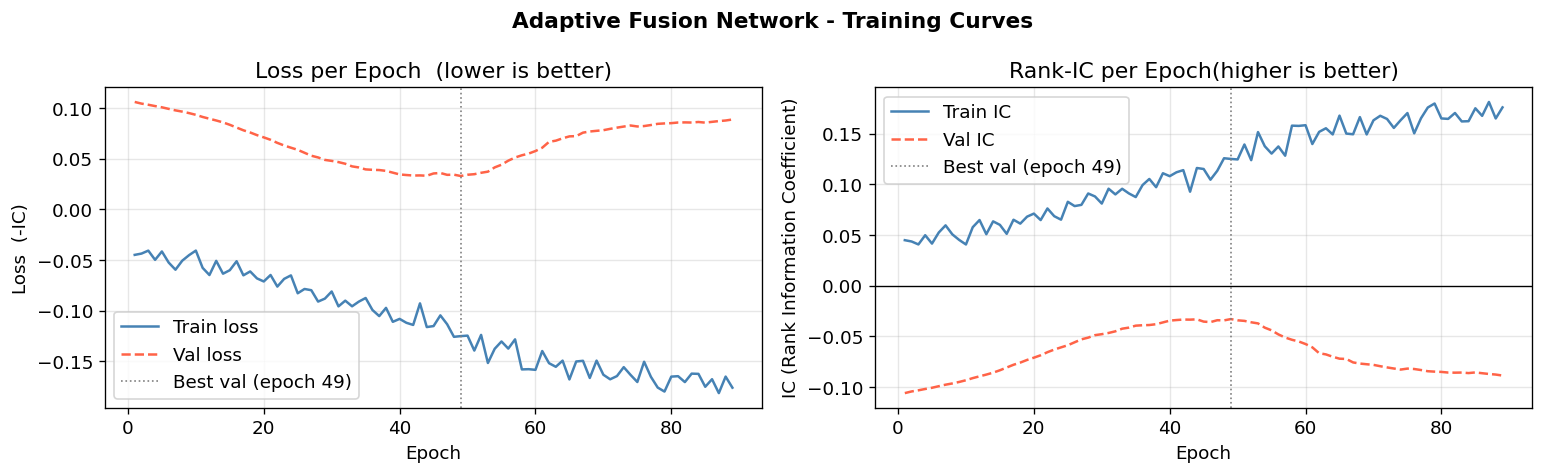

Best val IC   : -0.0330  at epoch 49
Final train IC: 0.1762
Overfit gap   : +0.2091   (overfit)


In [7]:
# Training curves (only available after a fresh training run)
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

if train_ic_history and val_ic_history:
    epochs = range(1, len(train_ic_history) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle("Adaptive Fusion Network - Training Curves", fontsize=13, fontweight="bold")

    # --- Loss (negative IC; lower is better) ---
    ax = axes[0]
    ax.plot(epochs, train_ic_history, label="Train loss", color="steelblue")
    ax.plot(epochs, val_ic_history,   label="Val loss",   color="tomato", linestyle="--")
    best_epoch = int(min(range(len(val_ic_history)), key=lambda i: val_ic_history[i])) + 1
    ax.axvline(best_epoch, color="grey", linestyle=":", linewidth=1, label=f"Best val (epoch {best_epoch})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss  (-IC)")
    ax.set_title("Loss per Epoch  (lower is better)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- IC (positive; higher is better) ---
    ax = axes[1]
    ax.plot(epochs, [-v for v in train_ic_history], label="Train IC", color="steelblue")
    ax.plot(epochs, [-v for v in val_ic_history],   label="Val IC",   color="tomato", linestyle="--")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.axvline(best_epoch, color="grey", linestyle=":", linewidth=1, label=f"Best val (epoch {best_epoch})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("IC (Rank Information Coefficient)")
    ax.set_title("Rank-IC per Epoch(higher is better)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_val_ic = max(-v for v in val_ic_history)
    final_train_ic = -train_ic_history[-1]
    print(f"Best val IC   : {best_val_ic:.4f}  at epoch {best_epoch}")
    print(f"Final train IC: {final_train_ic:.4f}")
    print(f"Overfit gap   : {final_train_ic - best_val_ic:+.4f}  ",
          "(overfit)" if final_train_ic - best_val_ic > 0.10 else "(healthy)")
else:
    print("No training history available. Set RETRAIN=True and re-run cell 10 to generate curves.")


---
## 5. Portfolio Optimiser (Black-Litterman + Sharpe MVO)

$$\mu_{BL} = \pi + \tau\Sigma\,(\tau\Sigma + \Omega)^{-1}(Q - \pi)$$

$$S(\mathbf{w}) = \frac{\mathbf{w}^\top \boldsymbol{\mu}_{BL}}{\sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}}$$

Constraints: $\sum w_i = 1$, $\ w_i \in [5\%,\ 20\%]$

| Symbol | Meaning |
|--------|---------|
| $\pi = \delta\Sigma w_{eq}$ | Equilibrium prior (equal-weight reference, $\delta=2.5$) |
| $Q$ | Absolute views: model composite scores scaled to daily-return units |
| $\Omega = \text{BL\_OMEGA\_SCALE} \cdot \text{diag}(\tau\Sigma)$ | Diagonal view uncertainty |
| $\tau = 0.5$ | Prior uncertainty scalar (calibrated for daily returns) |

The posterior is computed via the Woodbury identity, which is numerically stable when using
absolute views ($P = I$).

**Linear shrinkage regularisation** (Î»Â = 0.1, fixed) on Î£ mitigates the Markowitz optimisation enigma. The sample covariance is shrunk toward a scaled identity target: Î£Ì‚Â = (1-Î»)Î£Â +Â Î»Â·(tr(Î£)/n)Â·I. This is a simpler fixed-Î» variant; true Ledoit-Wolf (2004) estimates Î» analytically from the data.  
**Black-Litterman** replaces the raw historical mean with a
Bayesian posterior, weighting the equilibrium prior against the model's views according to their
relative uncertainty.

In [8]:
from scipy.optimize import minimize

def neg_sharpe(weights, expected_returns, covariance_matrix):
    portfolio_return = weights @ expected_returns
    portfolio_std    = np.sqrt(max(weights @ covariance_matrix @ weights, 1e-10))
    return -(portfolio_return / portfolio_std)

def optimise_weights(expected_returns, covariance_matrix, min_w=MIN_WEIGHT, max_w=MAX_WEIGHT):
    n_assets = len(expected_returns)
    if min_w * n_assets > 1.0: return np.full(n_assets, 1 / n_assets)
    initial_weights  = np.clip(np.full(n_assets, 1 / n_assets), min_w, max_w)
    initial_weights /= initial_weights.sum()
    opt_result = minimize(neg_sharpe, initial_weights,
                          args=(expected_returns, covariance_matrix),
                          method="SLSQP",
                          bounds=[(min_w, max_w)] * n_assets,
                          constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
                          options={"maxiter": 1000, "ftol": 1e-9})
    if opt_result.success:
        clipped_weights = np.clip(opt_result.x, min_w, max_w)
        return clipped_weights / clipped_weights.sum()
    return np.full(n_assets, 1 / n_assets)

def shrinkage_cov(returns, lam=0.1):
    sample_cov = returns.cov().values
    trace_mean = np.trace(sample_cov) / sample_cov.shape[0]
    return (1 - lam) * sample_cov + lam * trace_mean * np.eye(sample_cov.shape[0])

def black_litterman_mu(returns, tickers, composite_scores, Sigma=None):
    """
    Black-Litterman posterior: mu_BL = pi + tau*Sigma*(tau*Sigma + Omega)^-1*(Q - pi).
    See Section 5 markdown for full derivation.
    """
    n_assets = len(tickers)
    if Sigma is None:
        Sigma = shrinkage_cov(returns)

    # Equilibrium prior
    equal_weights       = np.full(n_assets, 1.0 / n_assets)
    equilibrium_returns = BL_DELTA * Sigma @ equal_weights

    # Scale composite scores to daily-return units
    score_array = np.array([composite_scores.get(ticker, 0.0) for ticker in tickers], dtype=float)
    return_std  = float(returns.std().values.mean())
    score_std   = float(score_array.std())
    view_returns = (score_array / score_std * return_std) if score_std > 1e-8 else equilibrium_returns.copy()

    # BL Woodbury update
    tau_cov              = BL_TAU * Sigma
    omega                = np.diag(np.diag(tau_cov)) * BL_OMEGA_SCALE
    prior_plus_omega     = tau_cov + omega
    try:
        prior_plus_omega_inv = np.linalg.inv(prior_plus_omega)
    except np.linalg.LinAlgError:
        return returns.mean().values

    bl_returns = equilibrium_returns + tau_cov @ prior_plus_omega_inv @ (view_returns - equilibrium_returns)
    return bl_returns


def allocate(close_panel, selected_tickers, composite_scores=None, lookback=60):
    available_tickers = [ticker for ticker in selected_tickers if ticker in close_panel.columns]
    returns           = close_panel[available_tickers].tail(lookback).pct_change().dropna()
    if len(returns) < 10:
        return {ticker: 1 / len(available_tickers) for ticker in available_tickers}

    covariance_matrix = shrinkage_cov(returns)

    if composite_scores:
        # Black-Litterman: model scores become views on the equilibrium prior
        expected_returns = black_litterman_mu(returns, available_tickers, composite_scores, Sigma=covariance_matrix)
    else:
        # No views available - fall back to historical mean returns
        expected_returns = returns.mean().values

    weights = optimise_weights(expected_returns, covariance_matrix)
    return {ticker: float(weight) for ticker, weight in zip(available_tickers, weights)}

print("Portfolio optimiser ready (Black-Litterman + Sharpe MVO).")

Portfolio optimiser ready (Black-Litterman + Sharpe MVO).


---
## 6. Backtest Engine

Execution price = **yfinance daily Open + slippage**.  
Price data is sourced entirely from **yfinance** (`auto_adjust=True`). Each trade uses the
day's opening price, adjusted upward by `SLIPPAGE_BPS` (default 5 bps) to model the cost of
crossing the bid-ask spread.

Rebalancing occurs every `REBALANCE_DAYS` (default 10) trading days. On each rebalance:
1. **Sells first** - positions whose target value is *below* current value are trimmed to free cash. If the target is *above* current (i.e. we want more of this ticker), the sell pass is skipped entirely and the position is only added to in step 2.
2. **Buys second** - new positions are opened and existing positions are topped up using the freed cash.

FINRA and SEC fees are applied on every sell (Modelled after T212 Fee structure).

In [9]:
def get_execution_price(date, ticker, price_data, slippage_bps=SLIPPAGE_BPS):
    """Return yfinance daily Open + slippage. None if data unavailable."""
    if ticker in price_data:
        ticker_prices = price_data[ticker]
        trade_date    = pd.Timestamp(date).normalize()
        if trade_date in ticker_prices.index:
            open_price = float(ticker_prices.loc[trade_date, "Open"])
            if open_price > 0:
                return open_price * (1 + slippage_bps / 10_000)
    return None


from dataclasses import dataclass, field as dc_field
from typing import Dict, List

@dataclass
class BacktestResult:
    name:              str
    nav_series:        pd.Series    = dc_field(default_factory=pd.Series)
    returns_series:    pd.Series    = dc_field(default_factory=pd.Series)
    weight_history:    pd.DataFrame = dc_field(default_factory=pd.DataFrame)
    attention_history: List[Dict]   = dc_field(default_factory=list)
    trade_log:         List[Dict]   = dc_field(default_factory=list)
    rebalance_dates:   List         = dc_field(default_factory=list)
    metrics:           Dict         = dc_field(default_factory=dict)

    def compute_metrics(self):
        daily_returns = self.returns_series.dropna()
        if len(daily_returns) < 2: return
        annualised_return = (1 + daily_returns).prod() ** (252 / len(daily_returns)) - 1
        annualised_vol    = daily_returns.std() * np.sqrt(252)
        sharpe_ratio      = annualised_return / annualised_vol if annualised_vol > 0 else 0.0
        nav_series        = self.nav_series
        max_drawdown      = ((nav_series - nav_series.cummax()) / nav_series.cummax()).min()
        self.metrics = {
            "Sharpe Ratio":      round(sharpe_ratio, 4),
            "Annualised Return": round(annualised_return, 4),
            "Annualised Vol":    round(annualised_vol, 4),
            "Max Drawdown":      round(max_drawdown, 4),
            "Calmar Ratio":      round(annualised_return / abs(max_drawdown), 4) if max_drawdown != 0 else float("nan"),
            "Total Return":      round((nav_series.iloc[-1] / nav_series.iloc[0]) - 1, 4),
        }

def transaction_costs(sell_proceeds, shares_sold, trade_value):
    return ((SLIPPAGE_BPS / 10_000) * trade_value
            + SEC_FEE_RATE * sell_proceeds
            + min(FINRA_TAF_PER_SH * shares_sold, 8.30))

def _build_panel(price_data, start, end, col):
    ticker_frames = {
        ticker: price_data[ticker].loc[
            (price_data[ticker].index >= start) & (price_data[ticker].index <= end), col]
        for ticker in price_data
    }
    return pd.DataFrame(ticker_frames).sort_index().ffill()

def _static_scores(date, feature_data, tickers, use_sentiment, weights):
    composite_scores = {}
    factor_weights   = np.array(weights, dtype=float)
    if not use_sentiment:
        factor_weights[0] = factor_weights[1] = 0
        total = factor_weights.sum()
        factor_weights = factor_weights / total if total > 0 else np.ones(N_FACTORS) / (N_FACTORS - 2)
    for ticker in tickers:
        ticker_df = feature_data.get(ticker)
        if ticker_df is None or date not in ticker_df.index: continue
        factor_row = ticker_df.loc[date, FACTOR_COLS].values.astype(np.float32)
        if not use_sentiment: factor_row[0] = factor_row[1] = 0
        composite_scores[ticker] = float(np.dot(factor_row, factor_weights))
    return composite_scores

def run_backtest(name, feature_data, price_data,
                 model=None, start=BACKTEST_START, end=BACKTEST_END,
                 initial_nav=INITIAL_NAV, top_n=TOP_N_STOCKS,
                 use_sentiment=True, use_adaptive=True, static_weights=None,
                 retrain_every=0):
    """
    Run a strategy backtest.

    Parameters
    ----------
    retrain_every : int
        Walk-forward retraining interval in trading days. 0 = no retraining.
        When > 0, the model is retrained (warm-started from previous weights)
        using an expanding window of data up to the current date.
    """
    static_weights        = static_weights or STATIC_WEIGHTS
    result                = BacktestResult(name=name)
    close_panel           = _build_panel(price_data, start, end, "Close")
    trading_days          = close_panel.index
    portfolio_nav         = initial_nav
    current_holdings      = {}
    available_cash        = initial_nav
    nav_by_date           = {}
    weight_records        = []
    attention_records     = []
    trade_records         = []
    rebalance_date_list   = []
    days_since_rebalance  = REBALANCE_DAYS
    days_since_retrain    = retrain_every  # trigger initial train on first rebalance

    for day_index, date in enumerate(trading_days):
        portfolio_nav = available_cash + sum(
            current_shares * close_panel.loc[date, ticker]
            for ticker, current_shares in current_holdings.items()
            if ticker in close_panel.columns
        )
        nav_by_date[date] = portfolio_nav

        if days_since_rebalance >= REBALANCE_DAYS:
            days_since_rebalance = 0

            # Use T-1 for signal/feature computation (T close prices unknown at T open)
            signal_date = trading_days[day_index - 1] if day_index > 0 else date

            # Walk-forward retraining (warm-started from current model weights)
            if use_adaptive and retrain_every > 0 and days_since_retrain >= retrain_every:
                days_since_retrain = 0
                prev_state = {k: v.clone() for k, v in model.state_dict().items()}
                model, _, _ = train_model(
                    feature_data, train_end=str(signal_date.date()),
                    verbose=False, warm_start_state=prev_state)

            valid_tickers = [
                ticker for ticker in feature_data
                if ticker in close_panel.columns and not np.isnan(close_panel.loc[date, ticker])
            ]
            attention_weights = {}
            if use_adaptive and model:
                composite_scores, attention_weights = get_composite_scores(
                    model, feature_data, signal_date, valid_tickers)
            else:
                composite_scores = _static_scores(
                    signal_date, feature_data, valid_tickers, use_sentiment, static_weights)
            if not composite_scores: days_since_rebalance += 1; continue

            ranked_tickers   = sorted(composite_scores.items(), key=lambda item: item[1], reverse=True)
            selected_tickers = [ticker for ticker, _ in ranked_tickers[:top_n]
                                 if not np.isnan(composite_scores[ticker])]
            if not selected_tickers: days_since_rebalance += 1; continue

            history_start_index = max(0, day_index - 60)
            price_history       = close_panel.loc[
                close_panel.index.isin(trading_days[history_start_index:day_index]),
                selected_tickers]
            target_weights = allocate(
                price_history, selected_tickers,
                {ticker: composite_scores[ticker] for ticker in selected_tickers},
                lookback=len(price_history))

            # Pass 1: sells only
            new_holdings         = {}
            total_sell_proceeds  = total_shares_sold = total_sell_value = 0.0

            for ticker, current_shares in current_holdings.items():
                if current_shares <= 0: continue
                execution_price = get_execution_price(date, ticker, price_data)
                if execution_price is None:
                    new_holdings[ticker] = current_shares
                    continue
                current_position_value = current_shares * execution_price
                target_position_value  = target_weights.get(ticker, 0) * portfolio_nav

                if target_position_value >= current_position_value:
                    new_holdings[ticker] = current_shares
                    continue

                if target_position_value < current_position_value - 1:
                    sell_amount    = current_position_value - target_position_value
                    shares_to_sell = sell_amount / execution_price
                    total_sell_proceeds += sell_amount
                    total_shares_sold   += shares_to_sell
                    total_sell_value    += sell_amount
                    new_holdings[ticker] = max(0, current_shares - shares_to_sell)
                    trade_records.append({
                        "date":   date,   "ticker": ticker, "action": "SELL",
                        "shares": shares_to_sell, "price": execution_price, "value": sell_amount,
                    })
                else:
                    new_holdings[ticker] = current_shares

            available_cash += total_sell_proceeds - transaction_costs(
                total_sell_proceeds, total_shares_sold, total_sell_value)

            # Pass 2: buys
            total_buy_value = 0
            pending_buys    = {}
            for ticker, target_weight in target_weights.items():
                execution_price        = get_execution_price(date, ticker, price_data)
                if execution_price is None: continue
                current_position_value = new_holdings.get(ticker, 0) * execution_price
                target_position_value  = target_weight * portfolio_nav
                if target_position_value > current_position_value + 1:
                    buy_amount    = target_position_value - current_position_value
                    shares_to_buy = buy_amount / execution_price
                    total_buy_value += buy_amount
                    pending_buys[ticker] = (shares_to_buy, execution_price)
                    trade_records.append({
                        "date":   date,   "ticker": ticker, "action": "BUY",
                        "shares": shares_to_buy, "price": execution_price, "value": buy_amount,
                    })

            available_cash -= total_buy_value * (1 + SLIPPAGE_BPS / 10_000)
            for ticker, (shares_to_buy, _) in pending_buys.items():
                new_holdings[ticker] = new_holdings.get(ticker, 0) + shares_to_buy

            current_holdings    = {ticker: share_count for ticker, share_count in new_holdings.items() if share_count > 1e-6}
            available_cash      = max(available_cash, 0.0)
            rebalance_date_list.append(date)
            weight_records.append({"date": date, **target_weights})
            if attention_weights: attention_records.append({"date": date, **attention_weights})

        days_since_rebalance += 1
        days_since_retrain   += 1

    result.nav_series        = pd.Series(nav_by_date, name=name)
    result.returns_series    = result.nav_series.pct_change().dropna()
    result.weight_history    = (pd.DataFrame(weight_records).set_index("date").fillna(0)
                                if weight_records else pd.DataFrame())
    result.attention_history = attention_records
    result.trade_log         = trade_records
    result.rebalance_dates   = rebalance_date_list
    result.compute_metrics()
    metrics = result.metrics
    print(f"[{name:20s}] Sharpe={metrics.get('Sharpe Ratio', 0):+.3f} | "
          f"Return={metrics.get('Total Return', 0) * 100:+.1f}% | "
          f"MaxDD={metrics.get('Max Drawdown', 0) * 100:.1f}%")
    return result


print("Backtest engine ready.")

Backtest engine ready.


---
## 7. Benchmark Strategies

Two naive benchmarks provide performance floors for the active strategies:

- **SPY Buy-and-Hold**: single entry at the backtest start, tracking the S&P 500 (`auto_adjust=True`). One-way slippage applied on entry only.
- **Equal-Weight**: 1/N allocation across all 20 tickers, rebalanced every `REBALANCE_DAYS` trading days with proportional slippage on each rebalance.

The remaining comparison strategies (Adaptive-Fusion, Static-Fusion, Price-Only) are executed via `run_backtest` in Section 8.

In [10]:
def run_spy_bah(spy_returns, start=BACKTEST_START, end=BACKTEST_END, initial_nav=INITIAL_NAV):
    date_mask          = (spy_returns.index >= start) & (spy_returns.index <= end)
    spy_period_returns = spy_returns[date_mask]
    nav_series         = initial_nav * (1 - SLIPPAGE_BPS / 10_000) * (1 + spy_period_returns).cumprod()
    result = BacktestResult(name="SPY Buy-and-Hold")
    result.nav_series     = pd.Series(nav_series, name="SPY Buy-and-Hold")
    result.returns_series = spy_period_returns
    result.compute_metrics()
    metrics = result.metrics
    print(f"[{'SPY Buy-and-Hold':20s}] Sharpe={metrics.get('Sharpe Ratio', 0):+.3f} | "
          f"Return={metrics.get('Total Return', 0) * 100:+.1f}% | "
          f"MaxDD={metrics.get('Max Drawdown', 0) * 100:.1f}%")
    return result

def run_equal_weight(price_data, start=BACKTEST_START, end=BACKTEST_END, initial_nav=INITIAL_NAV):
    close_panel= _build_panel(price_data, start, end, "Close")
    daily_returns = close_panel.pct_change().fillna(0)
    for day_index, date in enumerate(daily_returns.index):
        if day_index % REBALANCE_DAYS == 0:
            daily_returns.loc[date] -= SLIPPAGE_BPS / 10_000 * 0.3
    portfolio_returns = daily_returns.mean(axis=1)
    nav_series        = initial_nav * (1 + portfolio_returns).cumprod()
    result = BacktestResult(name="Equal-Weight")
    result.nav_series     = pd.Series(nav_series, name="Equal-Weight")
    result.returns_series = portfolio_returns
    result.compute_metrics()
    metrics = result.metrics
    print(f"[{'Equal-Weight':20s}] Sharpe={metrics.get('Sharpe Ratio', 0):+.3f} | "
          f"Return={metrics.get('Total Return', 0) * 100:+.1f}% | "
          f"MaxDD={metrics.get('Max Drawdown', 0) * 100:.1f}%")
    return result

print("Benchmark functions ready.")

Benchmark functions ready.


---
## 8. Run All Strategies

Executes the full pipeline for all five strategies in sequence using identical slippage, transaction costs, and rebalance frequency for a fair comparison.

| Strategy | Scores | Sentiment | Optimiser |
|----------|--------|-----------|-----------|
| Adaptive-Fusion | Trained fusion network | News + social | Black-Litterman + Sharpe MVO |
| Static-Fusion | Fixed equal weights on factors | News + social | Black-Litterman + Sharpe MVO |
| Price-Only | Fixed weights, sentiment zeroed | None | Black-Litterman + Sharpe MVO |
| Equal-Weight | - | - | 1/N rebalance |
| SPY Buy-and-Hold | - | - | Buy once, hold |

In [1]:
print("="*65)
print("RUNNING ALL STRATEGIES")
print("="*65)

# Load the saved pre-backtest model for the non-walk-forward variant
fixed_model = AdaptiveFusionNetwork(len(CONTEXT_COLS))
fixed_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
fixed_model.to(DEVICE).eval()

adaptive_wf_result = run_backtest(
    "Adaptive (WF)", feature_data, price_data,
    model=fusion_model, use_sentiment=True, use_adaptive=True,
    retrain_every=RETRAIN_EVERY)

adaptive_fixed_result = run_backtest(
    "Adaptive (Fixed)", feature_data, price_data,
    model=fixed_model, use_sentiment=True, use_adaptive=True,
    retrain_every=0)

static_result = run_backtest(
    "Static-Fusion", feature_data, price_data,
    model=None, use_sentiment=True, use_adaptive=False,
    static_weights=STATIC_WEIGHTS)

price_only_result = run_backtest(
    "Price-Only", feature_data, price_data,
    model=None, use_sentiment=False, use_adaptive=False,
    static_weights=[0, 0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

equal_weight_result = run_equal_weight(price_data)
spy_bah_result      = run_spy_bah(spy_returns)

all_results = {
    "Adaptive (WF)":    adaptive_wf_result,
    "Adaptive (Fixed)": adaptive_fixed_result,
    "Static-Fusion":    static_result,
    "Price-Only":       price_only_result,
    "Equal-Weight":     equal_weight_result,
    "SPY Buy-and-Hold": spy_bah_result,
}

# Keep reference for downstream cells that use adaptive_result
adaptive_result = adaptive_wf_result
print("="*65)

RUNNING ALL STRATEGIES


NameError: name 'AdaptiveFusionNetwork' is not defined

---
## 9. Results & Visualisations

| Figure | Description |
|--------|-------------|
| 1 | Portfolio NAV performance, all strategies rebased to 100 |
| 2 | Drawdown comparison across all strategies |
| 3 | Portfolio weight evolution: Adaptive Fusion (stacked area, all tickers) |
| 4 | Attention weight evolution: how the network reweights each factor over time |
| 5 | Average factor attribution: mean attention weight per factor across the backtest |

**Metrics reported per strategy:** Sharpe Ratio, Annualised Return, Annualised Volatility, Max Drawdown, Calmar Ratio, Total Return.  
All outputs are saved to `outputs/`.

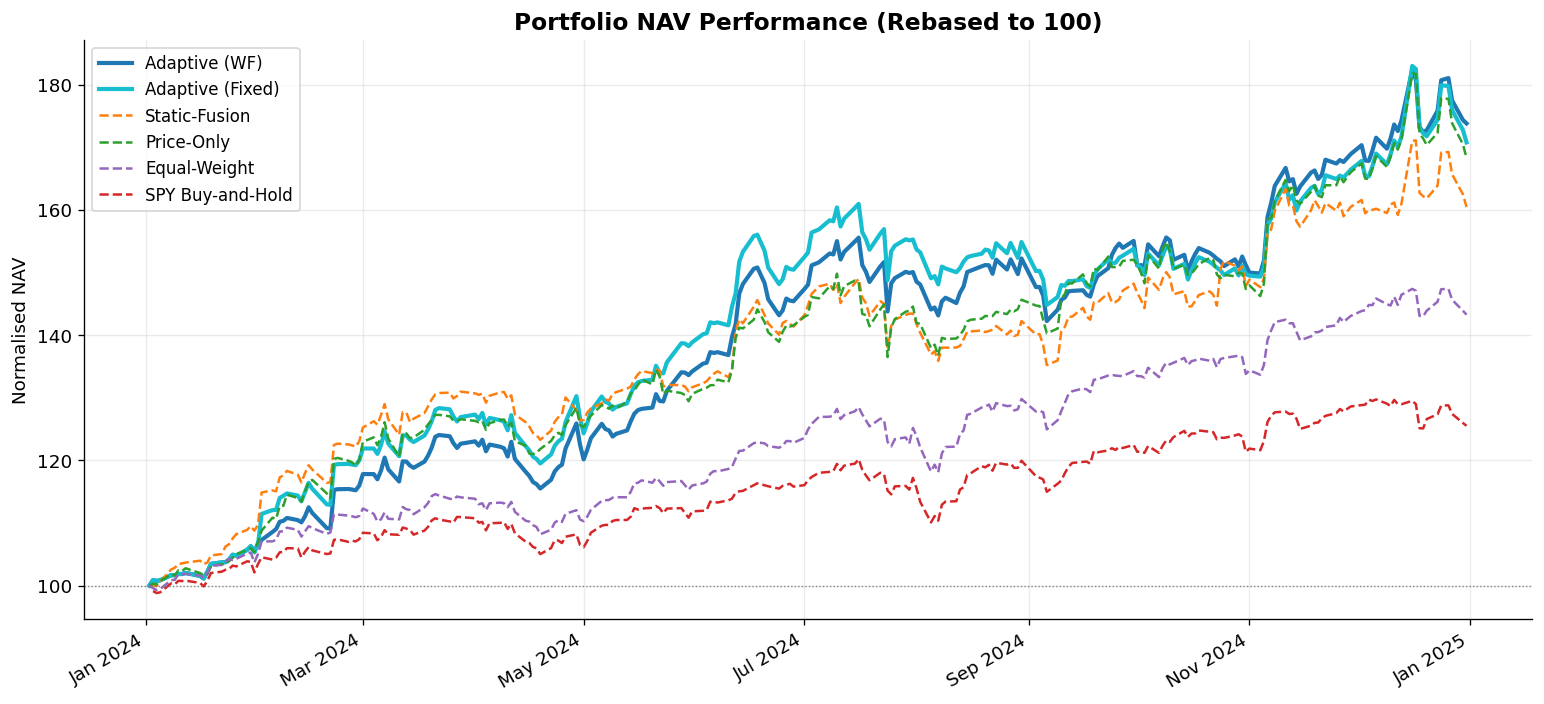

In [12]:
import matplotlib, matplotlib.pyplot as plt, matplotlib.dates as mdates
matplotlib.rcParams.update({"figure.dpi":120,"font.size":11,
    "axes.spines.top":False,"axes.spines.right":False})

COLORS = {"Adaptive (WF)":   "#1f77b4",
          "Adaptive (Fixed)": "#17becf",
          "Static-Fusion":    "#ff7f0e",
          "Price-Only":       "#2ca02c",
          "Equal-Weight":     "#9467bd",
          "SPY Buy-and-Hold": "#d62728"}

def fmt_ax(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right"); ax.grid(True,alpha=.25)

# Figure 1: NAV
fig, ax = plt.subplots(figsize=(13, 6))
for strategy_name, strategy_result in all_results.items():
    if strategy_result.nav_series.empty: continue
    nav_rebased = (strategy_result.nav_series / INITIAL_NAV) * 100
    is_adaptive = strategy_name.startswith("Adaptive")
    ax.plot(nav_rebased.index, nav_rebased.values,
            label=strategy_name,
            color=COLORS[strategy_name],
            lw=2.5 if is_adaptive else 1.5,
            ls="-"  if is_adaptive else "--")
ax.axhline(100, color="grey", lw=0.8, ls=":")
ax.set_title("Portfolio NAV Performance (Rebased to 100)", fontsize=14, fontweight="bold")
ax.set_ylabel("Normalised NAV"); fmt_ax(ax); ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"1_nav_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

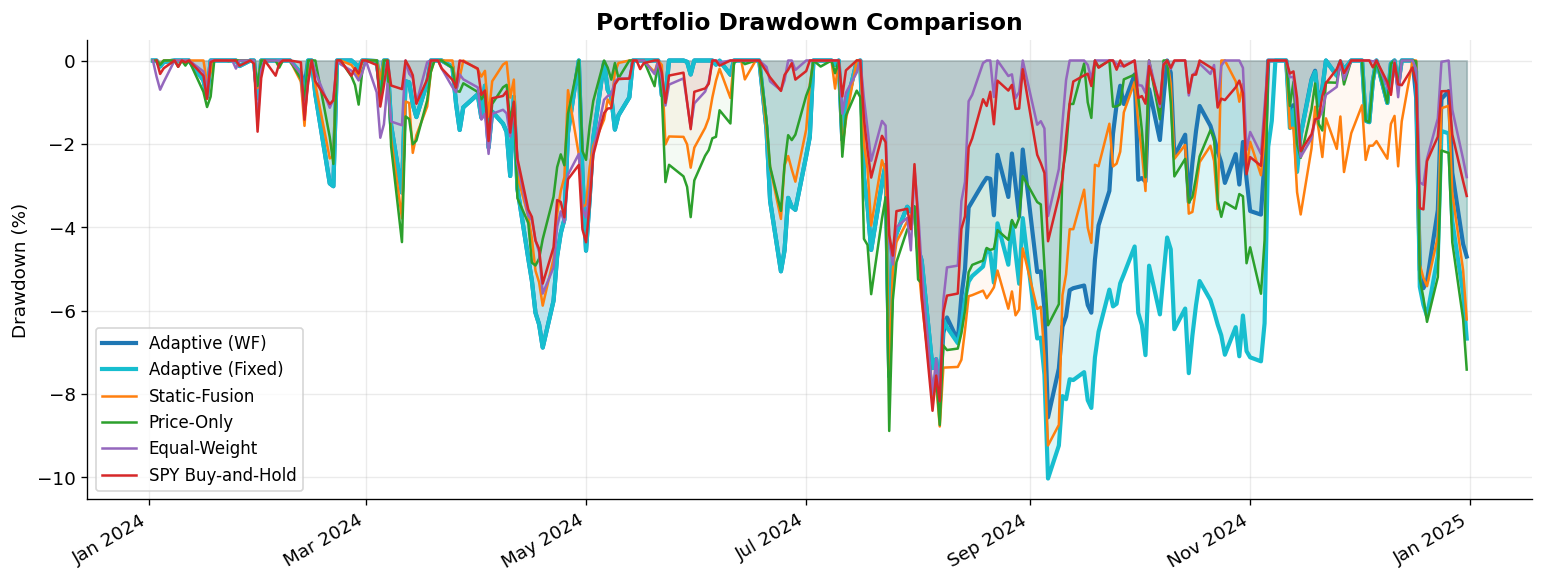

In [13]:
# Figure 2: Drawdown
fig, ax = plt.subplots(figsize=(13, 5))
for strategy_name, strategy_result in all_results.items():
    if strategy_result.nav_series.empty: continue
    nav_series = strategy_result.nav_series
    drawdown   = ((nav_series - nav_series.cummax()) / nav_series.cummax()) * 100
    is_adaptive = strategy_name.startswith("Adaptive")
    ax.plot(drawdown.index, drawdown.values,
            label=strategy_name,
            color=COLORS[strategy_name],
            lw=2.5 if is_adaptive else 1.5)
    ax.fill_between(drawdown.index, drawdown.values, 0,
                    color=COLORS[strategy_name],
                    alpha=0.15 if is_adaptive else 0.05)
ax.set_title("Portfolio Drawdown Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Drawdown (%)"); fmt_ax(ax); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"2_drawdown_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

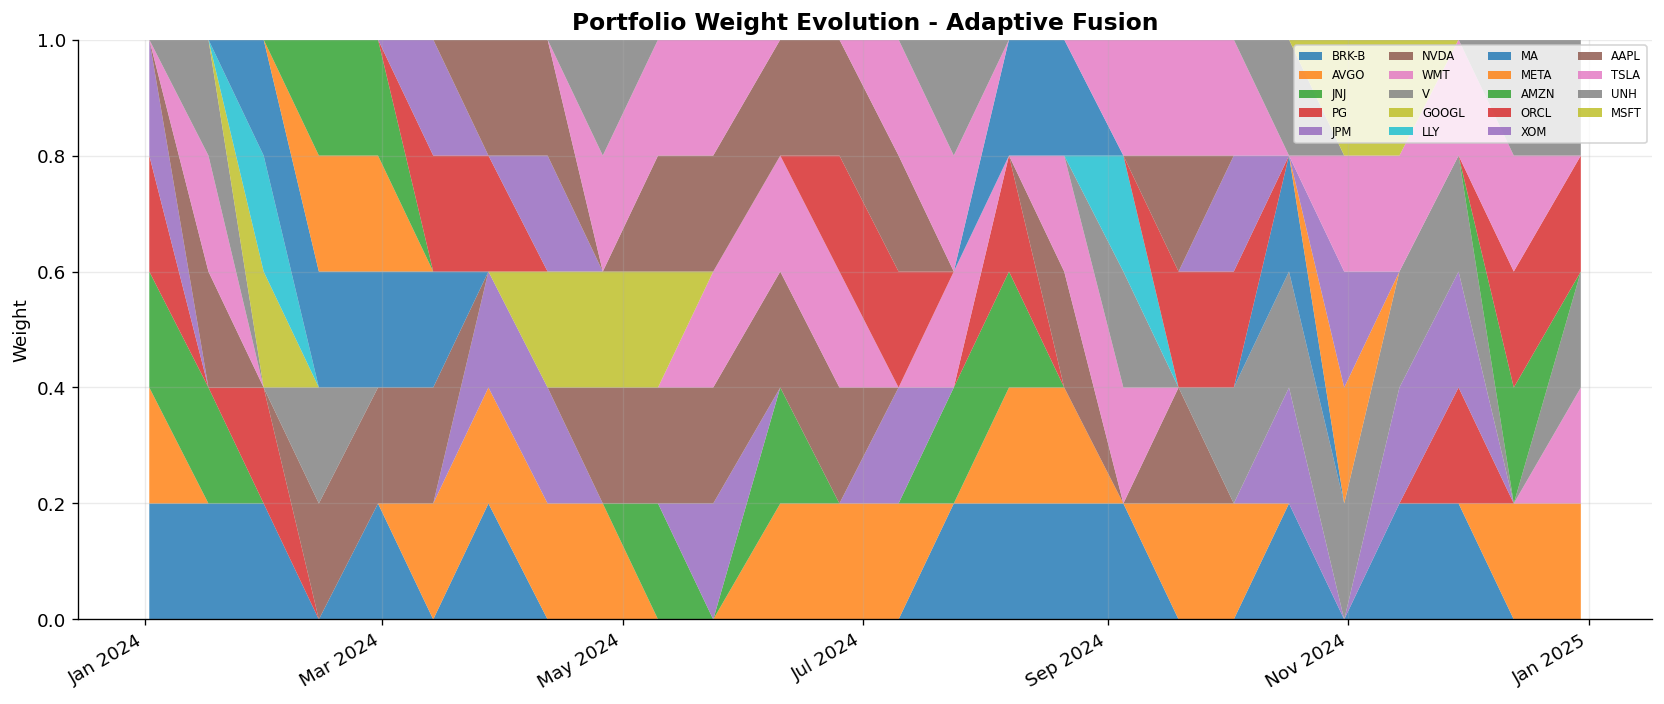

In [14]:
# Figure 3: Weight Evolution
if not adaptive_result.weight_history.empty:
    wh=adaptive_result.weight_history.fillna(0).clip(lower=0)
    all_tickers=wh.columns.tolist()
    fig,ax=plt.subplots(figsize=(14,6))
    ax.stackplot(wh.index,wh[all_tickers].T.values,labels=all_tickers,alpha=0.82)
    ax.set_title("Portfolio Weight Evolution - Adaptive Fusion",fontsize=14,fontweight="bold")
    ax.set_ylabel("Weight"); ax.set_ylim(0,1); ax.legend(loc="upper right",fontsize=7,ncol=4)
    fmt_ax(ax); plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"3_weight_evolution.png",dpi=300,bbox_inches="tight")
    plt.show()

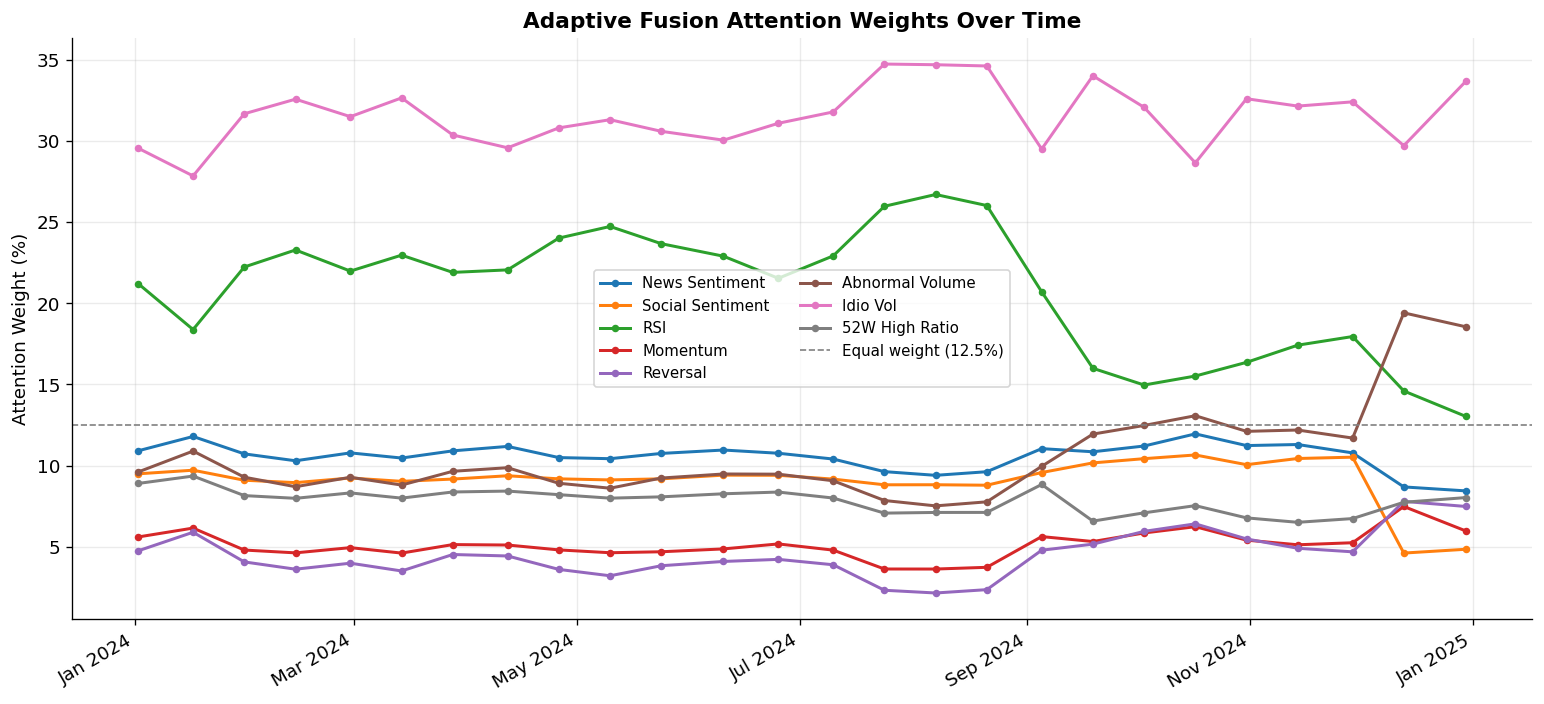

In [15]:
# Figure 4: Attention weights over time
rename = {"news_sentiment":"News Sentiment","social_sentiment":"Social Sentiment",
          "rsi":"RSI","momentum":"Momentum","reversal":"Reversal",
          "abnormal_volume":"Abnormal Volume","idiovol":"Idio Vol",
          "52w_high_ratio":"52W High Ratio"}

def _prep_attention(result):
    if not result.attention_history:
        return None
    df = pd.DataFrame(result.attention_history).set_index("date")
    df.columns = [col.replace("attn_z_","").replace("attn_","").replace("z_","",1) for col in df.columns]
    return df.rename(columns=rename)

af_attn = _prep_attention(adaptive_result)

if af_attn is not None:
    color_map = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(13, 6))

    equal_w = 100 / len(af_attn.columns)
    for i, col in enumerate(af_attn.columns):
        ax.plot(af_attn.index, af_attn[col] * 100,
                label=col, lw=1.8, marker="o", ms=3.5, color=color_map(i))
    ax.axhline(equal_w, color="grey", ls="--", lw=1,
               label=f"Equal weight ({equal_w:.1f}%)")
    ax.set_title("Adaptive Fusion Attention Weights Over Time", fontsize=13, fontweight="bold")
    ax.set_ylabel("Attention Weight (%)")
    ax.legend(fontsize=9, ncol=2)
    fmt_ax(ax)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"4_attention_weights.png", dpi=300, bbox_inches="tight")
    plt.show()

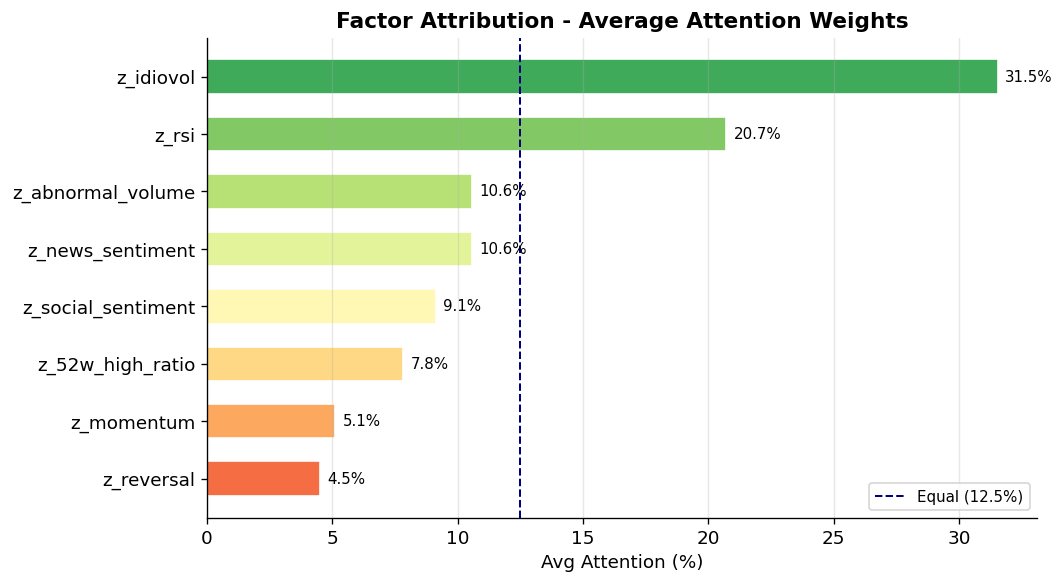

In [16]:
# Figure 5: Factor attribution
if adaptive_result.attention_history:
    attention_df = pd.DataFrame(adaptive_result.attention_history).drop(columns=["date"], errors="ignore")
    attention_df.columns = [col.replace("attn_z_","").replace("attn_","") for col in attention_df.columns]
    attention_df   = attention_df.rename(columns=rename)
    mean_attention = attention_df.mean().sort_values() * 100
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_colors = plt.get_cmap("RdYlGn")(np.linspace(0.2, 0.85, len(mean_attention)))
    bars = ax.barh(mean_attention.index, mean_attention.values,
                   color=bar_colors, edgecolor="white", height=0.6)
    equal_weight_pct = 100 / len(mean_attention)
    ax.axvline(equal_weight_pct, color="navy", lw=1.2, ls="--",
               label=f"Equal ({equal_weight_pct:.1f}%)")
    for bar, attention_value in zip(bars, mean_attention.values):
        ax.text(attention_value + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{attention_value:.1f}%", va="center", fontsize=9)
    ax.set_title("Factor Attribution - Average Attention Weights", fontsize=13, fontweight="bold")
    ax.set_xlabel("Avg Attention (%)")
    ax.legend(fontsize=9); ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"5_factor_attribution.png", dpi=300, bbox_inches="tight")
    plt.show()

In [17]:
# Metrics summary table
metric_rows = [{"Strategy": strategy_name, **strategy_result.metrics}
               for strategy_name, strategy_result in all_results.items()]
metrics_df  = pd.DataFrame(metric_rows).set_index("Strategy")
display_df  = metrics_df.copy()
for column_name in ["Annualised Return","Annualised Vol","Max Drawdown","Total Return"]:
    if column_name in display_df:
        display_df[column_name] = display_df[column_name].map(lambda x: f"{x*100:+.2f}%")
for column_name in ["Sharpe Ratio","Calmar Ratio"]:
    if column_name in display_df:
        display_df[column_name] = display_df[column_name].map(lambda x: f"{x:.4f}")
print("\n" + "="*70)
print("STRATEGY PERFORMANCE SUMMARY")
display(display_df)
metrics_df.to_csv(OUTPUT_DIR/"metrics_summary.csv")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")


STRATEGY PERFORMANCE SUMMARY


,Sharpe Ratio,Annualised Return,Annualised Vol,Max Drawdown,Calmar Ratio,Total Return
Strategy,,,,,,
Adaptive (WF),3.5706,+74.21%,+20.79%,-8.56%,8.6664,+73.83%
Adaptive (Fixed),3.2533,+71.16%,+21.87%,-10.03%,7.0937,+70.80%
Static-Fusion,2.8519,+60.79%,+21.32%,-9.24%,6.5812,+60.49%
Price-Only,3.1341,+68.65%,+21.91%,-8.89%,7.7228,+68.30%
Equal-Weight,3.2258,+43.28%,+13.42%,-8.10%,5.3399,+43.30%
SPY Buy-and-Hold,2.0437,+25.70%,+12.58%,-8.41%,3.0579,+26.62%



All outputs saved to: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\portfolio_optimizer\outputs


In [18]:
# Adaptive Fusion trade log
trade_log_df = pd.DataFrame(adaptive_result.trade_log)
trade_log_df["date"] = pd.to_datetime(trade_log_df["date"])
trade_log_df = trade_log_df.sort_values(["date", "ticker"]).reset_index(drop=True)
trade_log_df["shares"] = trade_log_df["shares"].round(6)
trade_log_df["price"]  = trade_log_df["price"].round(4)
trade_log_df["value"]  = trade_log_df["value"].round(2)

trade_log_df.to_csv(OUTPUT_DIR / "adaptive_fusion_trade_log.csv", index=False)

print(f"Total trades : {len(trade_log_df)}")
print(f"Buys         : {(trade_log_df['action']=='BUY').sum()}")
print(f"Sells        : {(trade_log_df['action']=='SELL').sum()}")
print(f"Tickers      : {sorted(trade_log_df['ticker'].unique())}")
print(f"\nSaved: {OUTPUT_DIR / 'adaptive_fusion_trade_log.csv'}")
print()
display(trade_log_df)

Total trades : 196
Buys         : 101
Sells        : 95
Tickers      : ['AAPL', 'AMZN', 'AVGO', 'BRK-B', 'GOOGL', 'JNJ', 'JPM', 'LLY', 'MA', 'META', 'MSFT', 'NVDA', 'ORCL', 'PG', 'TSLA', 'UNH', 'V', 'WMT', 'XOM']

Saved: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\portfolio_optimizer\outputs\adaptive_fusion_trade_log.csv



,date,ticker,action,shares,price,value
0,2024-01-02,AVGO,BUY,18.718022,106.8489,2000.00
1,2024-01-02,BRK-B,BUY,5.610127,356.4982,2000.00
2,2024-01-02,JNJ,BUY,13.615715,146.8891,2000.00
3,2024-01-02,JPM,BUY,12.416406,161.0772,2000.00
4,2024-01-02,PG,BUY,14.469978,138.2172,2000.00
...,...,...,...,...,...,...
191,2024-12-30,ORCL,BUY,1.041031,164.5177,171.27
192,2024-12-30,TSLA,SELL,8.294498,419.6097,3480.45
193,2024-12-30,UNH,BUY,0.124307,494.9251,61.52
194,2024-12-30,V,BUY,11.179168,311.9736,3487.61


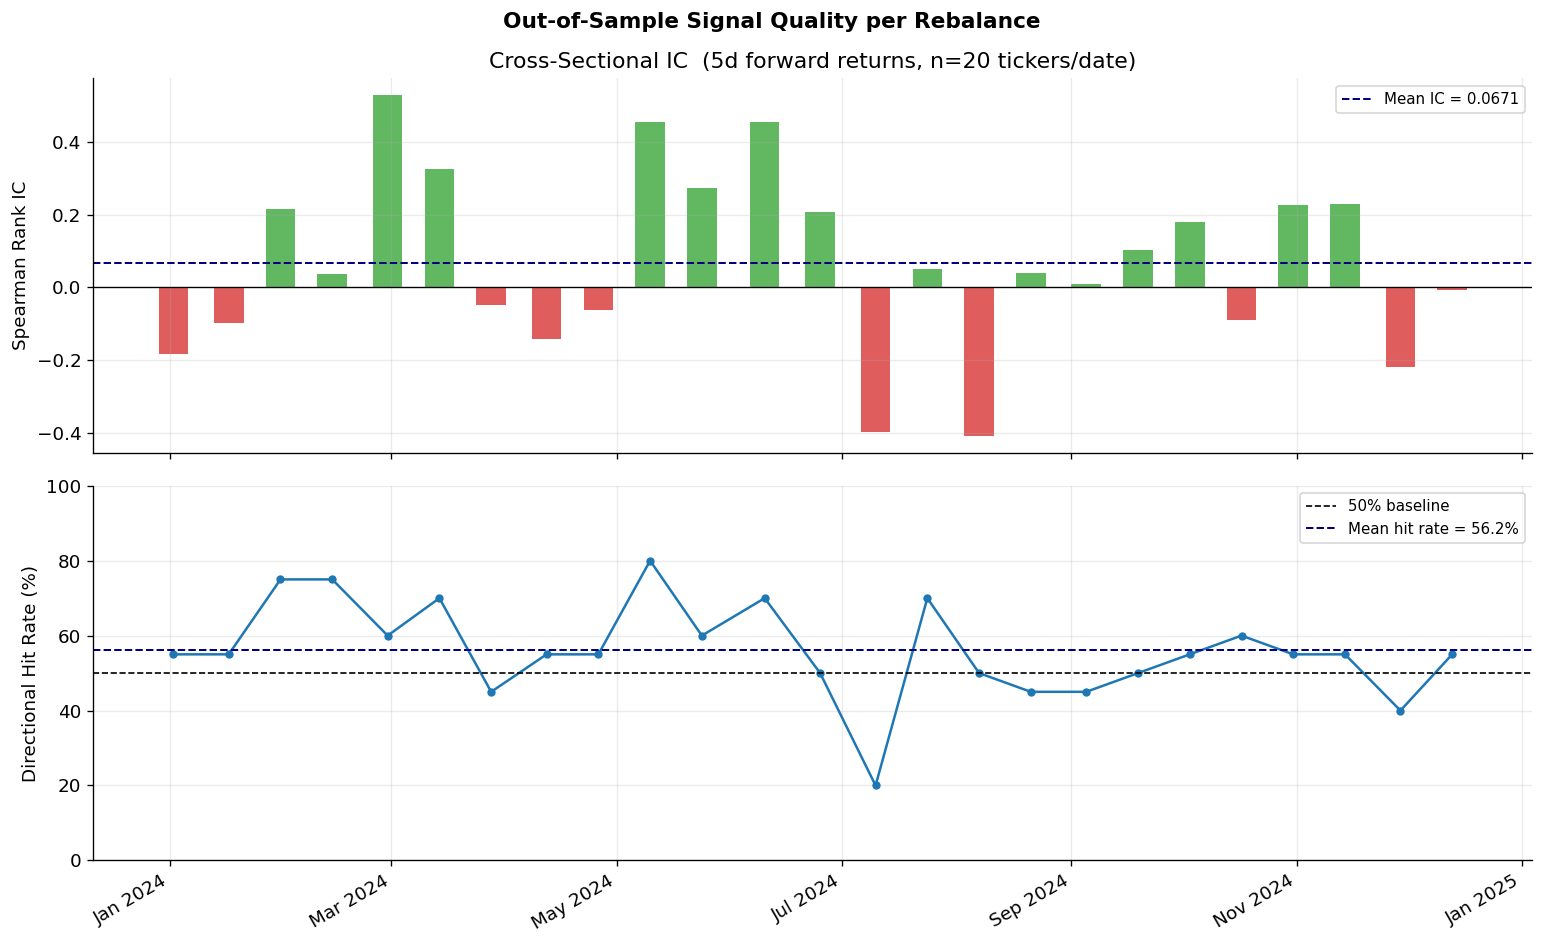

OOS IC Summary (25 rebalance dates):
  Mean IC        : +0.0671
  Median IC      : +0.0406
  % positive IC  : 60.0%
  Mean hit rate  : 56.2%
  IC t-stat      : 1.36


In [19]:
# Figure 8: Out-of-Sample Spearman IC per Rebalance Date
from scipy.stats import spearmanr

oos_ic_records = []
target_col = f"fwd_return_{FWD_HORIZON}d"

for date in adaptive_result.rebalance_dates:
    scores, realised = [], []
    for ticker in TICKERS:
        if ticker not in feature_data or date not in feature_data[ticker].index:
            continue
        row = feature_data[ticker].loc[date]
        if pd.isna(row.get(target_col)):
            continue
        f_ten = torch.tensor(row[FACTOR_COLS].values.astype(np.float32)).unsqueeze(0).to(DEVICE)
        c_ten = torch.tensor(row[CONTEXT_COLS].values.astype(np.float32)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            s, _ = fusion_model(f_ten, c_ten)
        scores.append(float(s.squeeze().cpu().item()))
        realised.append(float(row[target_col]))
    if len(scores) >= 5:
        ic, pval = spearmanr(scores, realised)
        hit = np.mean([1 if (s > 0) == (r > 0) else 0 for s, r in zip(scores, realised)])
        oos_ic_records.append({"date": date, "IC": ic, "p_value": pval, "hit_rate": hit, "n": len(scores)})

oos_ic_df = pd.DataFrame(oos_ic_records).set_index("date")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle("Out-of-Sample Signal Quality per Rebalance", fontsize=13, fontweight="bold")

# IC panel
ax = axes[0]
colors = ["#2ca02c" if v > 0 else "#d62728" for v in oos_ic_df["IC"]]
ax.bar(oos_ic_df.index, oos_ic_df["IC"], color=colors, alpha=0.75, width=8)
ax.axhline(0, color="black", lw=0.8)
mean_ic = oos_ic_df["IC"].mean()
ax.axhline(mean_ic, color="navy", ls="--", lw=1.2, label=f"Mean IC = {mean_ic:.4f}")
ax.set_ylabel("Spearman Rank IC")
ax.set_title(f"Cross-Sectional IC  ({FWD_HORIZON}d forward returns, n={int(oos_ic_df['n'].mean())} tickers/date)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# Hit rate panel
ax = axes[1]
ax.plot(oos_ic_df.index, oos_ic_df["hit_rate"] * 100, marker="o", ms=4, color="#1f77b4", lw=1.5)
ax.axhline(50, color="black", ls="--", lw=1, label="50% baseline")
mean_hr = oos_ic_df["hit_rate"].mean() * 100
ax.axhline(mean_hr, color="navy", ls="--", lw=1.2, label=f"Mean hit rate = {mean_hr:.1f}%")
ax.set_ylabel("Directional Hit Rate (%)")
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
fmt_ax(ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "8_oos_ic_hit_rate.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"OOS IC Summary ({len(oos_ic_df)} rebalance dates):")
print(f"  Mean IC        : {mean_ic:+.4f}")
print(f"  Median IC      : {oos_ic_df['IC'].median():+.4f}")
print(f"  % positive IC  : {(oos_ic_df['IC'] > 0).mean():.1%}")
print(f"  Mean hit rate  : {mean_hr:.1f}%")
print(f"  IC t-stat      : {mean_ic / (oos_ic_df['IC'].std() / np.sqrt(len(oos_ic_df))):.2f}")

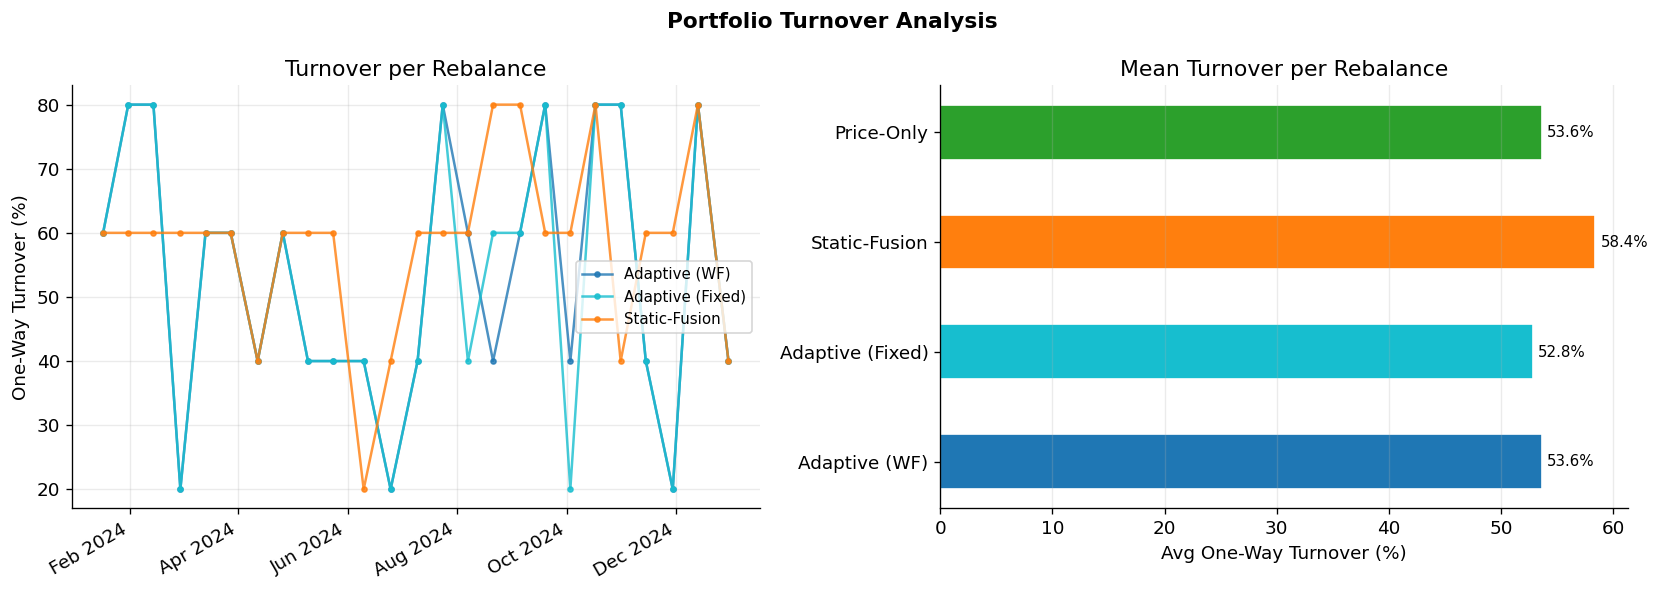

  Adaptive (WF)         trades= 196  est. total costs=$98.77  avg turnover=53.6%  rebalances=26
  Adaptive (Fixed)      trades= 196  est. total costs=$98.48  avg turnover=52.8%  rebalances=26
  Static-Fusion         trades= 203  est. total costs=$106.63  avg turnover=58.4%  rebalances=26
  Price-Only            trades= 197  est. total costs=$98.50  avg turnover=53.6%  rebalances=26


In [20]:
# Figure 9: Portfolio Turnover per Rebalance
turnover_records = {}
for strategy_name, strategy_result in all_results.items():
    if strategy_result.weight_history.empty or len(strategy_result.weight_history) < 2:
        continue
    wh = strategy_result.weight_history.fillna(0)
    # Turnover = sum of |w_t - w_{t-1}| / 2 at each rebalance
    diffs = wh.diff().iloc[1:].abs().sum(axis=1) / 2
    turnover_records[strategy_name] = diffs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Portfolio Turnover Analysis", fontsize=13, fontweight="bold")

# Left: turnover over time for adaptive strategies
ax = axes[0]
for strategy_name, turnover_series in turnover_records.items():
    if not strategy_name.startswith("Adaptive") and strategy_name != "Static-Fusion":
        continue
    ax.plot(turnover_series.index, turnover_series.values * 100,
            label=strategy_name, color=COLORS.get(strategy_name, "grey"),
            lw=1.5, marker="o", ms=3, alpha=0.8)
ax.set_ylabel("One-Way Turnover (%)")
ax.set_title("Turnover per Rebalance")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
fmt_ax(ax)

# Right: average turnover bar chart
ax = axes[1]
avg_turnover = {name: series.mean() * 100 for name, series in turnover_records.items()}
bars = ax.barh(list(avg_turnover.keys()), list(avg_turnover.values()),
               color=[COLORS.get(n, "grey") for n in avg_turnover.keys()],
               edgecolor="white", height=0.5)
for bar, val in zip(bars, avg_turnover.values()):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Avg One-Way Turnover (%)")
ax.set_title("Mean Turnover per Rebalance")
ax.grid(True, axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "9_turnover_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# Transaction cost summary
for strategy_name, strategy_result in all_results.items():
    trades = strategy_result.trade_log
    if not trades:
        continue
    trade_df = pd.DataFrame(trades)
    sell_df = trade_df[trade_df["action"] == "SELL"]
    total_cost = sum(
        transaction_costs(row["value"], row["shares"], row["value"])
        for _, row in sell_df.iterrows()
    )
    n_rebal = len(strategy_result.rebalance_dates)
    print(f"  {strategy_name:20s}  trades={len(trade_df):4d}  "
          f"est. total costs=${total_cost:.2f}  "
          f"avg turnover={avg_turnover.get(strategy_name, 0):.1f}%  "
          f"rebalances={n_rebal}")

Stationary Bootstrap: 2000 resamples, geometric block length ~ 10 days
Strategy                     Sharpe              95% CI    p vs SPY
----------------------------------------------------------------------
  Adaptive (WF)             +3.5706  [+1.1668, +7.2555]      0.2070
  Adaptive (Fixed)          +3.2533  [+0.7976, +6.7494]      0.2555
  Static-Fusion             +2.8519  [+0.7512, +5.9693]      0.3245
  Price-Only                +3.1341  [+1.0115, +6.3958]      0.2625
  Equal-Weight              +3.2258  [+1.1619, +6.3014]      0.2335
  SPY Buy-and-Hold          +2.0437  [+0.2050, +4.4850]         ---


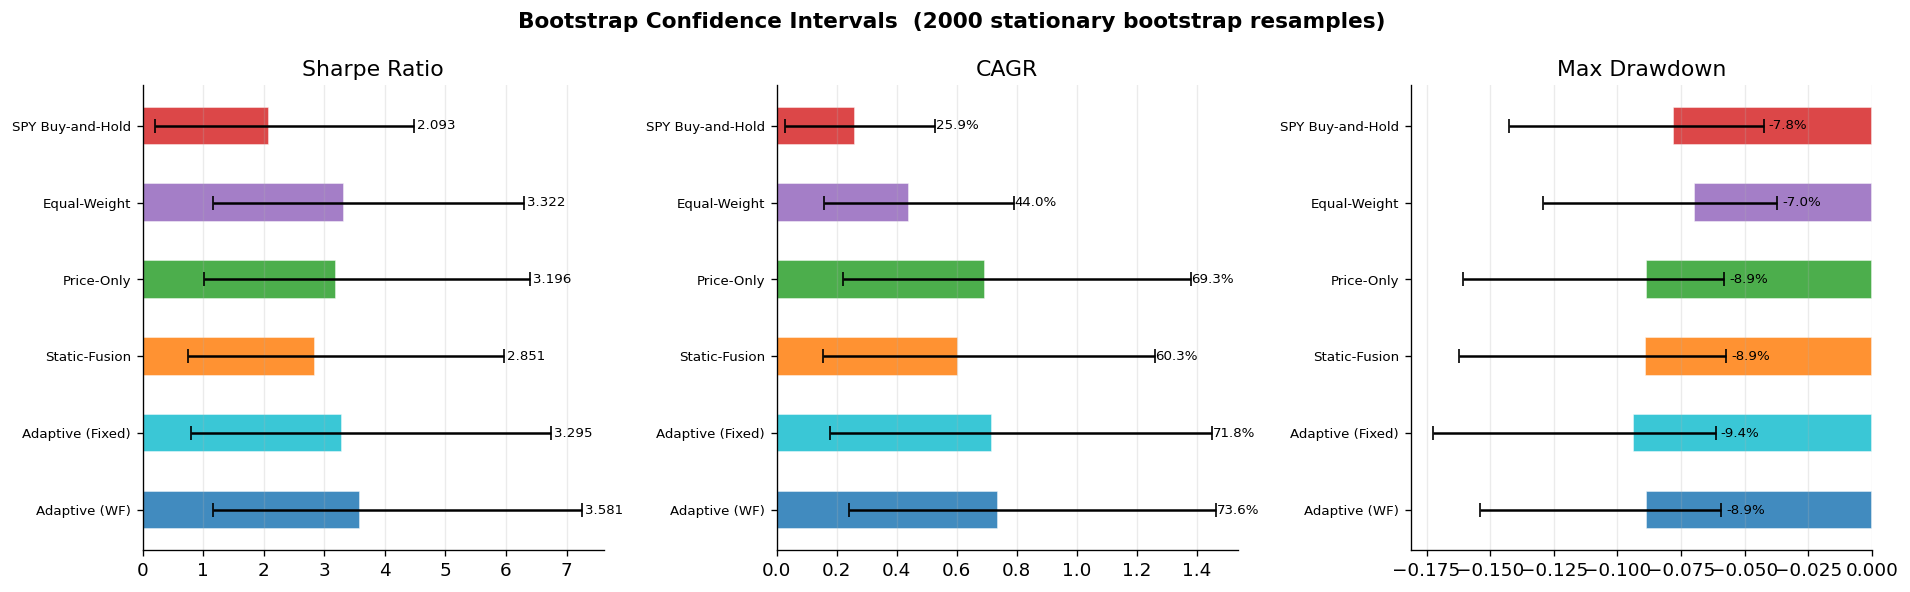


Bootstrap CI saved to C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\portfolio_optimizer\outputs\bootstrap_ci.csv


In [21]:
# Figure 10: Stationary Bootstrap Confidence Intervals (2000 resamples)

N_BOOTSTRAP    = 2000
BLOCK_LENGTH   = 10   # geometric mean block length for stationary bootstrap

def stationary_bootstrap(returns, n_resamples, block_length):
    """Stationary bootstrap of Politis & Romano (1994).
    Block lengths are drawn from Geometric(1/block_length)."""
    n = len(returns)
    p = 1.0 / block_length
    boot_samples = np.empty((n_resamples, n))
    for b in range(n_resamples):
        idx = np.random.randint(0, n)
        for t in range(n):
            boot_samples[b, t] = returns[idx % n]
            if np.random.random() < p:
                idx = np.random.randint(0, n)
            else:
                idx += 1
    return boot_samples

def compute_sharpe(rets):
    if len(rets) < 2 or rets.std() == 0:
        return 0.0
    ann_ret = (1 + rets).prod() ** (252 / len(rets)) - 1
    ann_vol = rets.std() * np.sqrt(252)
    return ann_ret / ann_vol

def compute_cagr(rets):
    total = (1 + rets).prod()
    years = len(rets) / 252
    return total ** (1 / years) - 1 if years > 0 else 0.0

def compute_maxdd(rets):
    cum = (1 + rets).cumprod()
    return ((cum - np.maximum.accumulate(cum)) / np.maximum.accumulate(cum)).min()

np.random.seed(RANDOM_SEED)

boot_results = {}
for strategy_name, strategy_result in all_results.items():
    rets = strategy_result.returns_series.dropna().values
    if len(rets) < 20:
        continue
    boot_matrix = stationary_bootstrap(rets, N_BOOTSTRAP, BLOCK_LENGTH)
    sharpes = np.array([compute_sharpe(boot_matrix[i]) for i in range(N_BOOTSTRAP)])
    cagrs   = np.array([compute_cagr(boot_matrix[i])   for i in range(N_BOOTSTRAP)])
    maxdds  = np.array([compute_maxdd(boot_matrix[i])   for i in range(N_BOOTSTRAP)])
    boot_results[strategy_name] = {
        "sharpe": sharpes, "cagr": cagrs, "maxdd": maxdds,
        "sharpe_ci": np.percentile(sharpes, [2.5, 97.5]),
        "cagr_ci":   np.percentile(cagrs,   [2.5, 97.5]),
        "maxdd_ci":  np.percentile(maxdds,  [2.5, 97.5]),
    }

# Paired bootstrap test: each strategy vs SPY
spy_rets = all_results["SPY Buy-and-Hold"].returns_series.dropna().values
spy_boot = stationary_bootstrap(spy_rets, N_BOOTSTRAP, BLOCK_LENGTH)
spy_sharpes = np.array([compute_sharpe(spy_boot[i]) for i in range(N_BOOTSTRAP)])

print(f"Stationary Bootstrap: {N_BOOTSTRAP} resamples, geometric block length ~ {BLOCK_LENGTH} days")
print(f"{'Strategy':25s}  {'Sharpe':>8s}  {'95% CI':>18s}  {'p vs SPY':>10s}")
print("-" * 70)
for strategy_name in all_results:
    if strategy_name not in boot_results:
        continue
    br = boot_results[strategy_name]
    point = all_results[strategy_name].metrics.get("Sharpe Ratio", 0)
    ci = br["sharpe_ci"]
    if strategy_name == "SPY Buy-and-Hold":
        pval_str = "---"
    else:
        diff = br["sharpe"] - spy_sharpes
        pval = (diff <= 0).mean()
        pval_str = f"{pval:.4f}"
    print(f"  {strategy_name:23s}  {point:+8.4f}  [{ci[0]:+.4f}, {ci[1]:+.4f}]  {pval_str:>10s}")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Bootstrap Confidence Intervals  ({N_BOOTSTRAP} stationary bootstrap resamples)",
             fontsize=13, fontweight="bold")

metrics_list = [
    ("sharpe", "sharpe_ci", "Sharpe Ratio"),
    ("cagr",   "cagr_ci",   "CAGR"),
    ("maxdd",  "maxdd_ci",  "Max Drawdown"),
]

for ax, (key, ci_key, title) in zip(axes, metrics_list):
    names, medians, lows, highs = [], [], [], []
    for strategy_name in all_results:
        if strategy_name not in boot_results:
            continue
        br = boot_results[strategy_name]
        ci = br[ci_key]
        names.append(strategy_name)
        medians.append(np.median(br[key]))
        lows.append(ci[0])
        highs.append(ci[1])

    y_pos = np.arange(len(names))
    colors_list = [COLORS.get(n, "grey") for n in names]
    errors = np.array([[m - l, h - m] for m, l, h in zip(medians, lows, highs)]).T
    ax.barh(y_pos, medians, xerr=errors, capsize=4,
            color=colors_list, edgecolor="white", height=0.5, alpha=0.85)
    for i, (m, l, h) in enumerate(zip(medians, lows, highs)):
        if key == "cagr" or key == "maxdd":
            ax.text(h + 0.002, i, f"{m*100:.1f}%", va="center", fontsize=8)
        else:
            ax.text(h + 0.05, i, f"{m:.3f}", va="center", fontsize=8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.25)
    ax.axvline(0, color="black", lw=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_bootstrap_ci.png", dpi=300, bbox_inches="tight")
plt.show()

# Save bootstrap summary
boot_summary = []
for strategy_name in all_results:
    if strategy_name not in boot_results:
        continue
    br = boot_results[strategy_name]
    boot_summary.append({
        "Strategy": strategy_name,
        "Sharpe (point)": all_results[strategy_name].metrics.get("Sharpe Ratio", 0),
        "Sharpe 2.5%": br["sharpe_ci"][0],
        "Sharpe 97.5%": br["sharpe_ci"][1],
        "CAGR 2.5%": br["cagr_ci"][0],
        "CAGR 97.5%": br["cagr_ci"][1],
        "MaxDD 2.5%": br["maxdd_ci"][0],
        "MaxDD 97.5%": br["maxdd_ci"][1],
    })
pd.DataFrame(boot_summary).set_index("Strategy").to_csv(OUTPUT_DIR / "bootstrap_ci.csv")
print(f"\nBootstrap CI saved to {OUTPUT_DIR / 'bootstrap_ci.csv'}")

## 12. Rolling Window Analysis

Tests whether strategy performance is sensitive to the choice of backtest entry date.
The fixed trained model (no retraining) is run across every 1-year window
whose start date falls within the backtest period (2024-10-10 to 2026-02-16), stepping one trading day at a time.

| Metric tracked | Interpretation |
|----------------|----------------|
| Sharpe ratio per window | Is edge consistent or clustered in one period? |
| % windows beating SPY | Reliability of outperformance across entry dates |
| Total return distribution | Sensitivity to starting conditions |

In [22]:
def _metrics_from_rets(rets):
    """Compute Sharpe and Total Return from a 1-D array of daily returns."""
    rets = rets[~np.isnan(rets)]
    if len(rets) < 2:
        return {"Sharpe": np.nan, "Total Return": np.nan}
    ann_ret = (1 + rets).prod() ** (252 / len(rets)) - 1
    ann_vol = rets.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0
    total   = (1 + rets).prod() - 1
    return {"Sharpe": round(sharpe, 4), "Total Return": round(total, 4)}


ROLL_START_RANGE = BACKTEST_START
ROLL_END_RANGE   = "2026-02-16"  # last window START date; each window ends +1 year

# Load the saved trained model for the fixed (no walk-forward) variant
rolling_fixed_model = AdaptiveFusionNetwork(len(CONTEXT_COLS))
rolling_fixed_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
rolling_fixed_model.to(DEVICE).eval()
print(f"Loaded trained model from {MODEL_PATH.name} for rolling window analysis")

# Fetch SPY for the full rolling period (wider than original spy_returns)
print("Fetching extended SPY returns")
spy_wide = fetch_spy_returns(BACKTEST_START, BACKTEST_END)

# Trading dates that fall in the start-date range
all_trading = sorted(price_data[TICKERS[0]].index)
window_starts = [
    d for d in all_trading
    if pd.Timestamp(ROLL_START_RANGE) <= d <= pd.Timestamp(ROLL_END_RANGE)
]
oos_boundary = pd.Timestamp(BACKTEST_START)   # in-sample / OOS split

print(f"Windows          : {len(window_starts)}")
print(f"Start range      : {window_starts[0].date()}  to  {window_starts[-1].date()}")
print(f"OOS boundary     : {oos_boundary.date()}")
print(f"In-sample windows: {sum(d < oos_boundary for d in window_starts)}")
print(f"OOS windows      : {sum(d >= oos_boundary for d in window_starts)}")
print()

rolling_records = []

for i, start_dt in enumerate(window_starts, 1):
    end_dt    = start_dt + pd.DateOffset(years=1)
    start_str = start_dt.strftime("%Y-%m-%d")
    end_str   = end_dt.strftime("%Y-%m-%d")

    try:
        # Walk-forward variant: retrain every RETRAIN_EVERY days
        # Start from the saved checkpoint each window
        wf_model = AdaptiveFusionNetwork(len(CONTEXT_COLS))
        wf_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
        wf_model.to(DEVICE).eval()

        r_wf = run_backtest(
            f"WF_{start_str}", feature_data, price_data,
            model=wf_model, use_sentiment=True, use_adaptive=True,
            start=start_str, end=end_str, retrain_every=RETRAIN_EVERY)
        m_wf = r_wf.metrics

        # Fixed variant: no retraining, inference only
        r_fx = run_backtest(
            f"FX_{start_str}", feature_data, price_data,
            model=rolling_fixed_model, use_sentiment=True, use_adaptive=True,
            start=start_str, end=end_str, retrain_every=0)
        m_fx = r_fx.metrics
    except Exception as e:
        print(f"  [{i:3d}] {start_str} FAILED: {e}")
        continue

    if not m_wf or not m_fx:
        print(f"  [{i:3d}] {start_str} SKIPPED: backtest returned empty metrics (too few trading days)")
        continue

    spy_w = spy_wide.loc[start_str:end_str].dropna()
    spy_m = _metrics_from_rets(spy_w.values) if len(spy_w) >= 20 else None

    rolling_records.append({
        "start":             start_dt,
        "end":               end_dt,
        "in_sample":         start_dt < oos_boundary,
        "WF_Sharpe":         m_wf["Sharpe Ratio"],
        "WF_Total_Return":   m_wf["Total Return"],
        "WF_Ann_Return":     m_wf["Annualised Return"],
        "WF_Max_Drawdown":   m_wf["Max Drawdown"],
        "FX_Sharpe":         m_fx["Sharpe Ratio"],
        "FX_Total_Return":   m_fx["Total Return"],
        "FX_Ann_Return":     m_fx["Annualised Return"],
        "FX_Max_Drawdown":   m_fx["Max Drawdown"],
        "SPY_Sharpe":        spy_m["Sharpe"]       if spy_m else np.nan,
        "SPY_Total_Return":  spy_m["Total Return"] if spy_m else np.nan,
    })

    if i % 10 == 0 or i == len(window_starts):
        tag = "IS" if start_dt < oos_boundary else "OOS"
        spy_s = rolling_records[-1]["SPY_Sharpe"]
        print(f"  [{i:3d}/{len(window_starts)}] {start_str} [{tag}]  "
              f"WF={m_wf['Sharpe Ratio']:+.3f}  Fixed={m_fx['Sharpe Ratio']:+.3f}  SPY={spy_s:+.3f}")

rolling_df = pd.DataFrame(rolling_records)
rolling_df["WF_beats_spy"] = rolling_df["WF_Sharpe"] > rolling_df["SPY_Sharpe"]
rolling_df["FX_beats_spy"] = rolling_df["FX_Sharpe"] > rolling_df["SPY_Sharpe"]
rolling_df["WF_beats_FX"]  = rolling_df["WF_Sharpe"] > rolling_df["FX_Sharpe"]

# Summary
print(f"\nRolling Window Summary")
print("=" * 60)
for label, mask in [("All windows", slice(None)),
                     ("In-sample windows",  rolling_df["in_sample"]),
                     ("Out-of-sample only", ~rolling_df["in_sample"])]:
    sub = rolling_df[mask] if isinstance(mask, pd.Series) else rolling_df
    if len(sub) == 0:
        continue
    print(f"\n{label}  (n={len(sub)}):")
    for variant, prefix in [("Walk-Forward", "WF"), ("Fixed Model", "FX")]:
        cols = [f"{prefix}_Sharpe", f"{prefix}_Total_Return", f"{prefix}_Max_Drawdown"]
        desc = sub[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
        print(f"\n  {variant}:")
        display(desc.round(4))
        print(f"    Pct windows beating SPY : {sub[f'{prefix}_beats_spy'].mean():.1%}")
    print(f"  Walk-forward beats fixed : {sub['WF_beats_FX'].mean():.1%}")

Loaded trained model from fusion_network.pt for rolling window analysis
Fetching extended SPY returns
Windows          : 252
Start range      : 2024-01-02  to  2024-12-31
OOS boundary     : 2024-01-01
In-sample windows: 0
OOS windows      : 252

[WF_2024-01-02       ] Sharpe=+4.002 | Return=+84.2% | MaxDD=-8.0%
[FX_2024-01-02       ] Sharpe=+3.253 | Return=+70.8% | MaxDD=-10.0%
[WF_2024-01-03       ] Sharpe=+3.528 | Return=+75.6% | MaxDD=-10.1%
[FX_2024-01-03       ] Sharpe=+3.951 | Return=+86.5% | MaxDD=-10.1%
[WF_2024-01-04       ] Sharpe=+2.655 | Return=+52.7% | MaxDD=-9.8%
[FX_2024-01-04       ] Sharpe=+2.921 | Return=+56.1% | MaxDD=-7.5%
[WF_2024-01-05       ] Sharpe=+3.433 | Return=+65.2% | MaxDD=-8.1%
[FX_2024-01-05       ] Sharpe=+3.376 | Return=+66.3% | MaxDD=-7.7%
[WF_2024-01-08       ] Sharpe=+5.557 | Return=+112.0% | MaxDD=-7.0%
[FX_2024-01-08       ] Sharpe=+5.227 | Return=+103.6% | MaxDD=-7.0%
[WF_2024-01-09       ] Sharpe=+4.902 | Return=+97.5% | MaxDD=-7.2%
[FX_2024-01-

,WF_Sharpe,WF_Total_Return,WF_Max_Drawdown
count,250.0000,250.0000,250.0000
mean,2.0161,0.2576,-0.0795
std,2.6651,0.2263,0.0261
min,-26.7346,-0.1118,-0.1605
5%,-2.1121,-0.0390,-0.1276
25%,1.3186,0.0982,-0.0983
50%,2.3753,0.2164,-0.0772
75%,3.4286,0.3924,-0.0580
95%,4.7358,0.6946,-0.0453
max,6.7808,1.1199,-0.0261


    Pct windows beating SPY : 75.6%

  Fixed Model:


,FX_Sharpe,FX_Total_Return,FX_Max_Drawdown
count,250.0000,250.0000,250.0000
mean,2.3581,0.2715,-0.0763
std,1.8224,0.2047,0.0205
min,-15.2402,-0.0629,-0.1294
5%,-0.2246,-0.0047,-0.1172
25%,1.8417,0.1330,-0.0901
50%,2.4572,0.2318,-0.0701
75%,3.2504,0.3684,-0.0629
95%,4.4277,0.6506,-0.0495
max,5.5707,1.0365,-0.0454


    Pct windows beating SPY : 88.8%
  Walk-forward beats fixed : 42.4%

Out-of-sample only  (n=250):

  Walk-Forward:


,WF_Sharpe,WF_Total_Return,WF_Max_Drawdown
count,250.0000,250.0000,250.0000
mean,2.0161,0.2576,-0.0795
std,2.6651,0.2263,0.0261
min,-26.7346,-0.1118,-0.1605
5%,-2.1121,-0.0390,-0.1276
25%,1.3186,0.0982,-0.0983
50%,2.3753,0.2164,-0.0772
75%,3.4286,0.3924,-0.0580
95%,4.7358,0.6946,-0.0453
max,6.7808,1.1199,-0.0261


    Pct windows beating SPY : 75.6%

  Fixed Model:


,FX_Sharpe,FX_Total_Return,FX_Max_Drawdown
count,250.0000,250.0000,250.0000
mean,2.3581,0.2715,-0.0763
std,1.8224,0.2047,0.0205
min,-15.2402,-0.0629,-0.1294
5%,-0.2246,-0.0047,-0.1172
25%,1.8417,0.1330,-0.0901
50%,2.4572,0.2318,-0.0701
75%,3.2504,0.3684,-0.0629
95%,4.4277,0.6506,-0.0495
max,5.5707,1.0365,-0.0454


    Pct windows beating SPY : 88.8%
  Walk-forward beats fixed : 42.4%


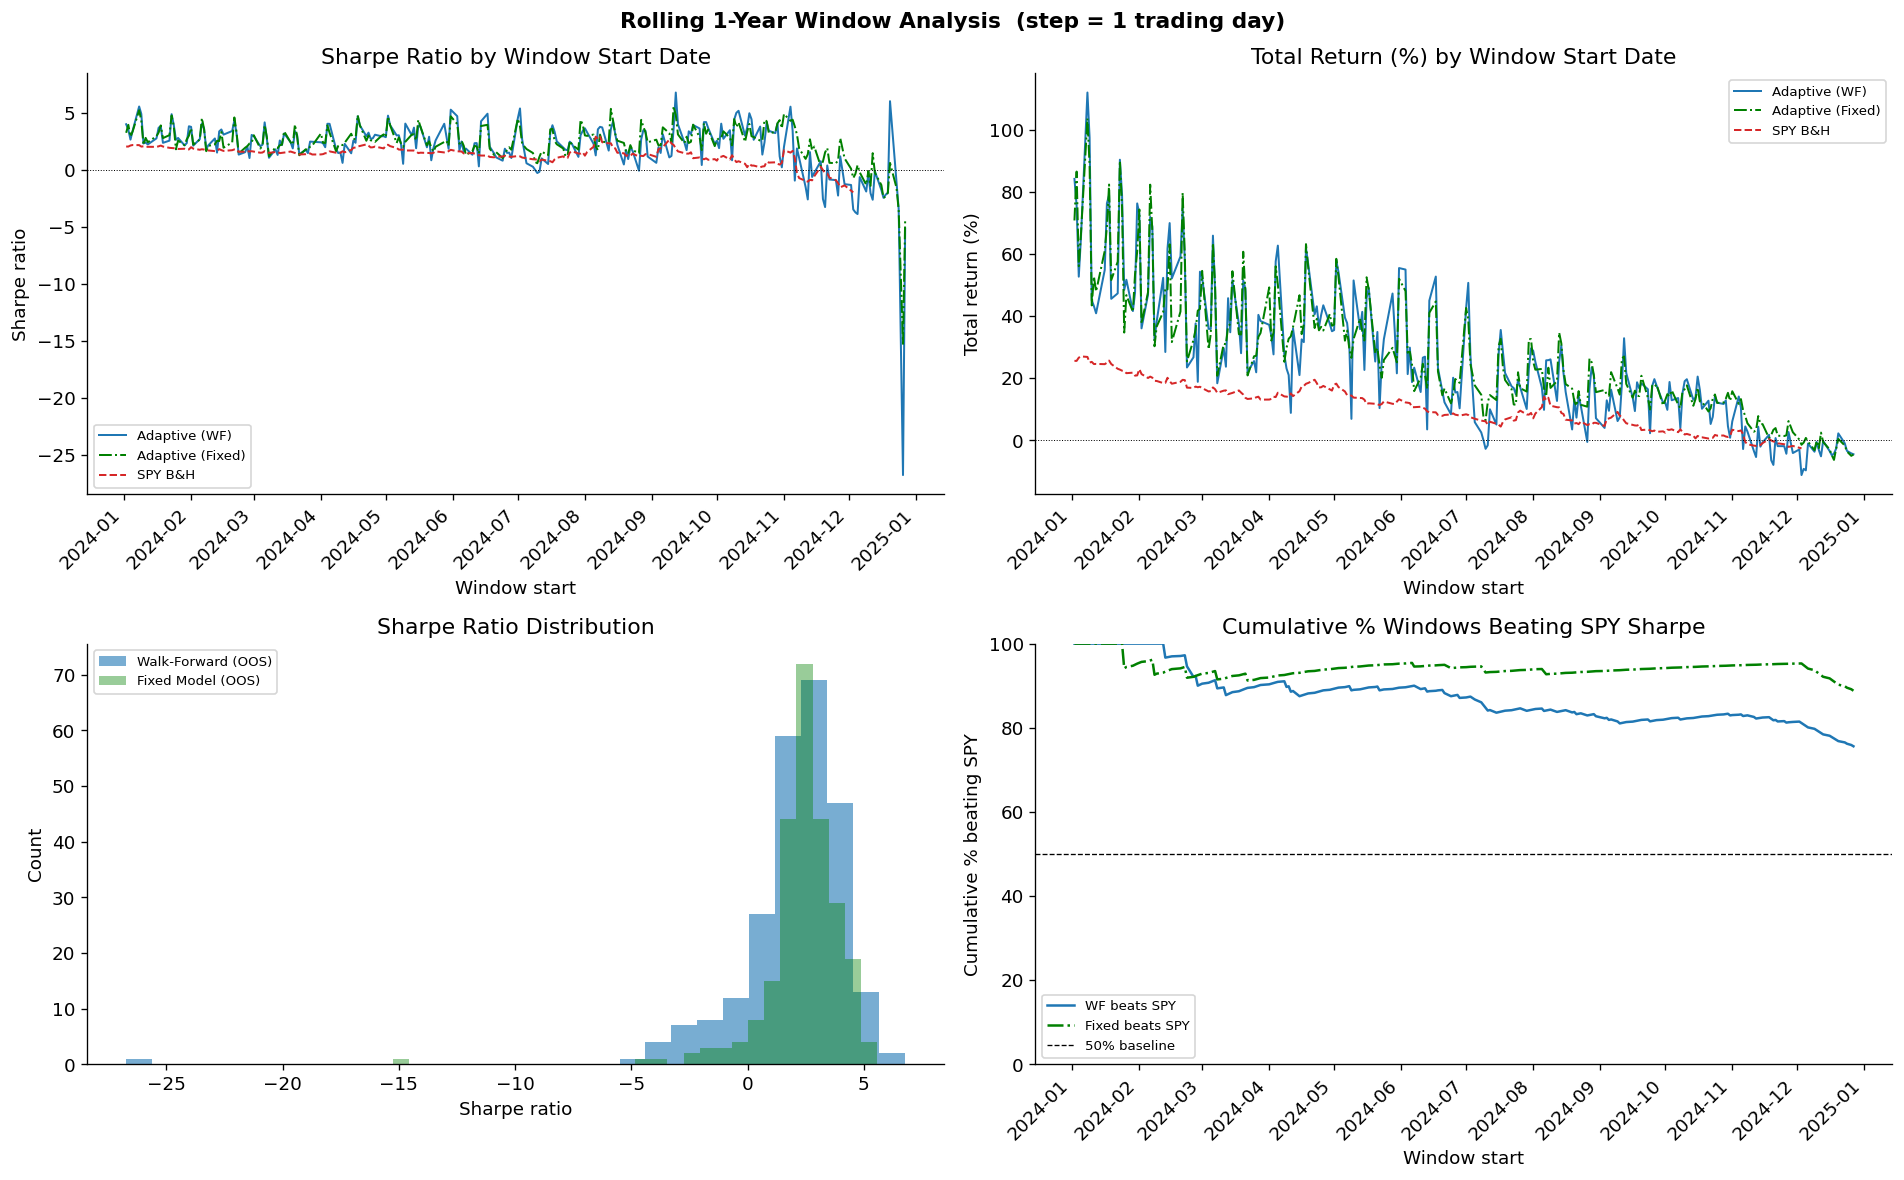

In [29]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Rolling 1-Year Window Analysis  (step = 1 trading day)",
             fontsize=13, fontweight="bold")

is_mask  = rolling_df["in_sample"]
oos_mask = ~rolling_df["in_sample"]

def _apply_month_fmt(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Top-left: Sharpe ratio
ax = axes[0, 0]
if is_mask.any():
    ax.axvspan(rolling_df.loc[is_mask, "start"].min(),
               rolling_df.loc[is_mask, "start"].max(),
               alpha=0.10, color="orange", label="In-sample region")
ax.plot(rolling_df["start"], rolling_df["WF_Sharpe"],
        color="#1f77b4", linewidth=1.2, label="Adaptive (WF)")
ax.plot(rolling_df["start"], rolling_df["FX_Sharpe"],
        color="green", linewidth=1.2, linestyle="-.", label="Adaptive (Fixed)")
ax.plot(rolling_df["start"], rolling_df["SPY_Sharpe"],
        color="#d62728", linewidth=1.2, linestyle="--", label="SPY B&H")
ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title("Sharpe Ratio by Window Start Date")
ax.set_xlabel("Window start")
ax.set_ylabel("Sharpe ratio")
ax.legend(fontsize=8)
_apply_month_fmt(ax)

# Top-right: Total return
ax = axes[0, 1]
if is_mask.any():
    ax.axvspan(rolling_df.loc[is_mask, "start"].min(),
               rolling_df.loc[is_mask, "start"].max(),
               alpha=0.10, color="orange")
ax.plot(rolling_df["start"], rolling_df["WF_Total_Return"] * 100,
        color="#1f77b4", linewidth=1.2, label="Adaptive (WF)")
ax.plot(rolling_df["start"], rolling_df["FX_Total_Return"] * 100,
        color="green", linewidth=1.2, linestyle="-.", label="Adaptive (Fixed)")
ax.plot(rolling_df["start"], rolling_df["SPY_Total_Return"] * 100,
        color="#d62728", linewidth=1.2, linestyle="--", label="SPY B&H")
ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title("Total Return (%) by Window Start Date")
ax.set_xlabel("Window start")
ax.set_ylabel("Total return (%)")
ax.legend(fontsize=8)
_apply_month_fmt(ax)

# Bottom-left: Sharpe histogram (WF vs Fixed, OOS only)
ax = axes[1, 0]
bins = 30
if oos_mask.any():
    ax.hist(rolling_df.loc[oos_mask, "WF_Sharpe"], bins=bins,
            alpha=0.6, color="#1f77b4", label="Walk-Forward (OOS)")
    ax.hist(rolling_df.loc[oos_mask, "FX_Sharpe"], bins=bins,
            alpha=0.4, color="green", label="Fixed Model (OOS)")
if is_mask.any():
    ax.hist(rolling_df.loc[is_mask,  "WF_Sharpe"], bins=bins,
            alpha=0.3, color="orange", label="Walk-Forward (IS)")
ax.set_title("Sharpe Ratio Distribution")
ax.set_xlabel("Sharpe ratio")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

# Bottom-right: Cumulative % windows beating SPY
ax = axes[1, 1]
cum_beat_wf = rolling_df["WF_beats_spy"].expanding().mean() * 100
cum_beat_fx = rolling_df["FX_beats_spy"].expanding().mean() * 100
if is_mask.any():
    ax.axvspan(rolling_df.loc[is_mask, "start"].min(),
               rolling_df.loc[is_mask, "start"].max(),
               alpha=0.10, color="orange", label="In-sample region")
ax.plot(rolling_df["start"], cum_beat_wf,
        color="#1f77b4", linewidth=1.5, label="WF beats SPY")
ax.plot(rolling_df["start"], cum_beat_fx,
        color="green", linewidth=1.5, linestyle="-.", label="Fixed beats SPY")
ax.axhline(50, color="black", linewidth=0.8, linestyle="--", label="50% baseline")
ax.set_title("Cumulative % Windows Beating SPY Sharpe")
ax.set_xlabel("Window start")
ax.set_ylabel("Cumulative % beating SPY")
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
_apply_month_fmt(ax)

plt.tight_layout()
plt.show()

---
## 13. Attention Diagnostic: Per-Sector Ticker Trace (Option A)

Fixes one representative ticker per sector and runs inference at every rebalance date using
the pretrained `fusion_model`. Since the sector one-hot never changes for a given ticker,
**any variation in the attention line is caused solely by the three time-varying context
features** (volatility regime, news intensity, social intensity).

- **Flat line** = the model learned a static sector preference; regime has no effect for that ticker
- **Visible movement** = the model genuinely adapts to changing market conditions

This isolates the regime signal from the portfolio-composition confound in Figure 4.

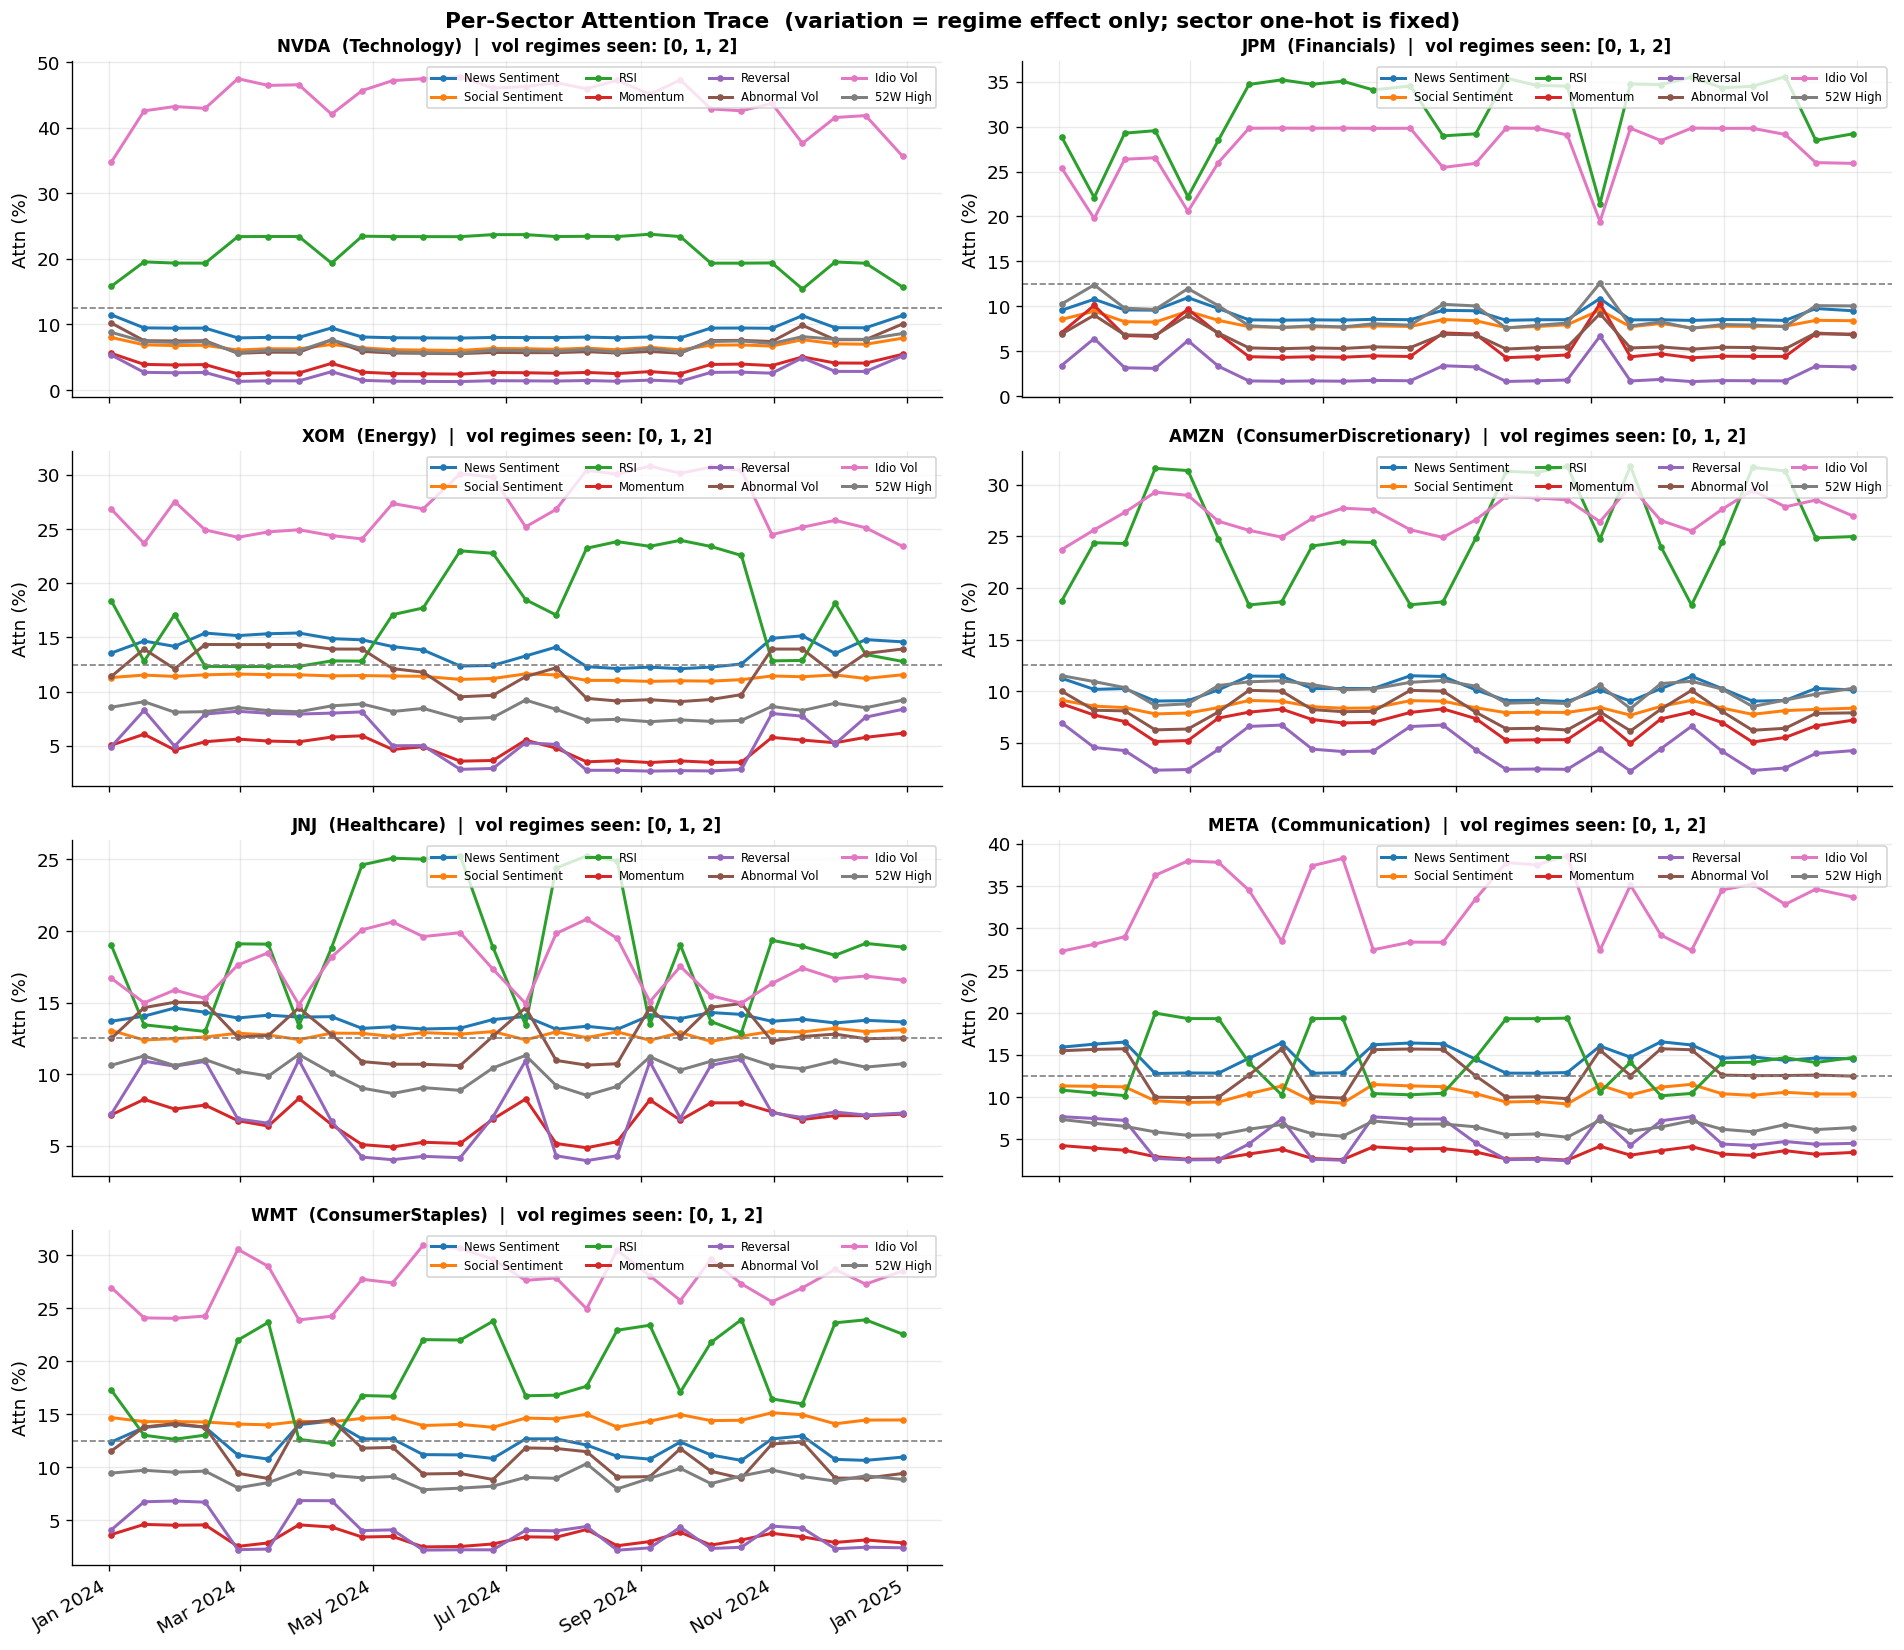

In [24]:
# Option A: per-sector ticker attention trace (fixed model, one rep per sector)
SECTOR_REPS = {
    "Technology":            "NVDA",
    "Financials":            "JPM",
    "Energy":                "XOM",
    "ConsumerDiscretionary": "AMZN",
    "Healthcare":            "JNJ",
    "Communication":         "META",
    "ConsumerStaples":       "WMT",
}
FACTOR_DISPLAY = ["News Sentiment", "Social Sentiment", "RSI", "Momentum",
                  "Reversal", "Abnormal Vol", "Idio Vol", "52W High"]

rebal_dates = adaptive_result.rebalance_dates
color_map   = plt.get_cmap("tab10")
ncols = 2
nrows = (len(SECTOR_REPS) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), sharex=True)
axes_flat  = axes.flatten()

fusion_model.eval()
for ax_idx, (sector, ticker) in enumerate(SECTOR_REPS.items()):
    ax = axes_flat[ax_idx]
    attn_rows = []
    vol_vals  = []
    for date in rebal_dates:
        if ticker not in feature_data or date not in feature_data[ticker].index:
            continue
        row   = feature_data[ticker].loc[date]
        f_ten = torch.tensor(row[FACTOR_COLS].values.astype(np.float32)).unsqueeze(0).to(DEVICE)
        c_ten = torch.tensor(row[CONTEXT_COLS].values.astype(np.float32)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            _, attn = fusion_model(f_ten, c_ten)
        attn_rows.append({"date": date,
                          **{f: float(v) for f, v in zip(FACTOR_DISPLAY, attn.squeeze().cpu().numpy())}})
        vol_vals.append(int(row["volatility_regime"]))
    if not attn_rows:
        ax.set_visible(False)
        continue
    df = pd.DataFrame(attn_rows).set_index("date")
    for i, col in enumerate(df.columns):
        ax.plot(df.index, df[col] * 100, label=col, lw=1.8, marker="o", ms=3, color=color_map(i))
    ax.axhline(100 / len(FACTOR_DISPLAY), color="grey", ls="--", lw=1)
    regimes_seen = sorted(set(vol_vals))
    ax.set_title(f"{ticker}  ({sector})  |  vol regimes seen: {regimes_seen}",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("Attn (%)")
    ax.legend(fontsize=7, ncol=4, loc="upper right")
    fmt_ax(ax)

if len(SECTOR_REPS) % ncols:
    axes_flat[-1].set_visible(False)

fig.suptitle("Per-Sector Attention Trace  (variation = regime effect only; sector one-hot is fixed)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "6_attention_per_sector_ticker.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 14. Attention Diagnostic: Grouped by Volatility Regime (Option B)

Runs inference for **all 20 tickers** at every rebalance date and groups the resulting
attention weights by each ticker's `volatility_regime` (0 = low, 1 = mid, 2 = high).
Error bars show one standard deviation across the grouped observations.

- **Bars at the same height across regimes** = the model does not differentiate by volatility; sector drives everything
- **Bars that differ across regimes** = the model has learned genuine regime-conditional factor preferences

This directly tests whether the three time-varying context inputs have any learned effect.

Observations per regime: {0: 1786, 1: 2160, 2: 2754}


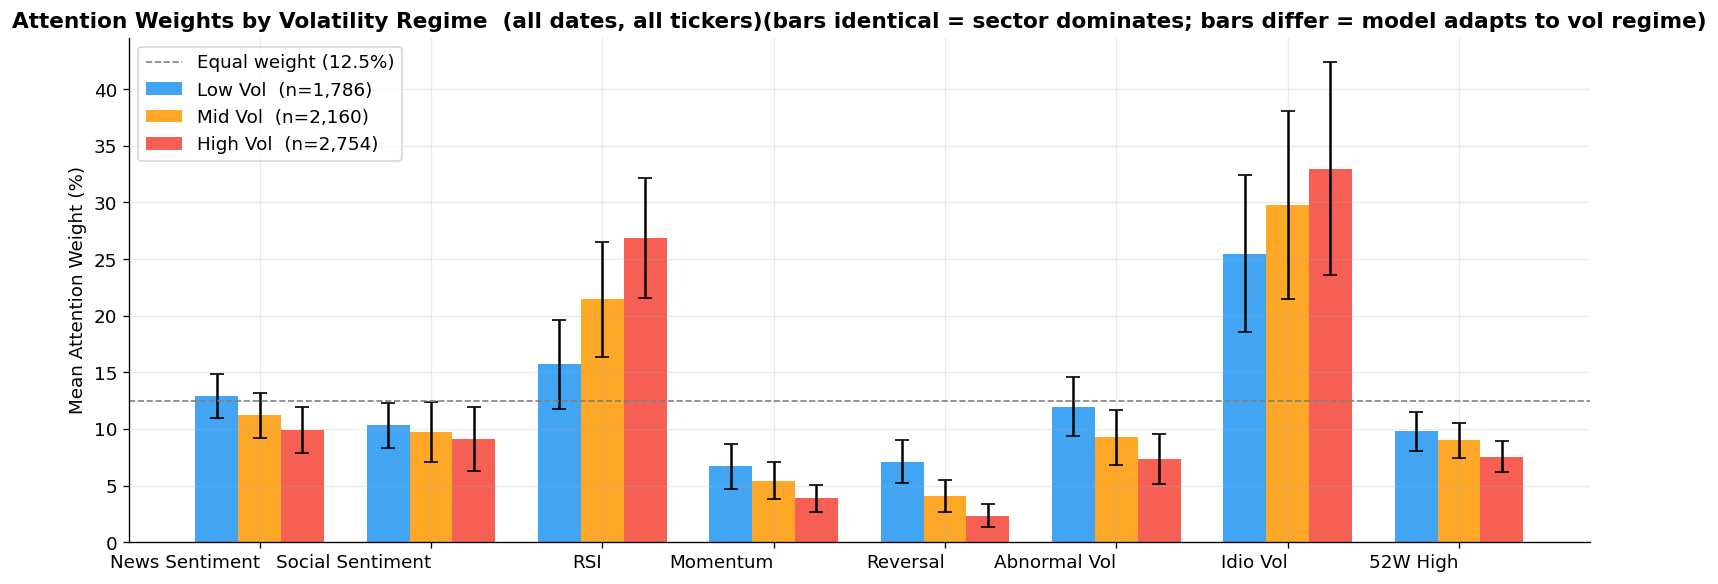

Figure 7 saved.


In [25]:
# Option B: attention grouped by volatility regime (all tickers, all available dates)
from collections import defaultdict

regime_attn    = defaultdict(list)
FACTOR_DISPLAY = ["News Sentiment", "Social Sentiment", "RSI", "Momentum",
                  "Reversal", "Abnormal Vol", "Idio Vol", "52W High"]

# Use all dates in feature_data (training + backtest) for a large, balanced sample
all_dates = sorted(set(
    date
    for df in feature_data.values()
    for date in df.index
    if df.loc[date, FACTOR_COLS + CONTEXT_COLS].notna().all()
))

fusion_model.eval()
with torch.no_grad():
    for date in all_dates:
        for ticker in TICKERS:
            if ticker not in feature_data or date not in feature_data[ticker].index:
                continue
            row = feature_data[ticker].loc[date]
            if row[FACTOR_COLS + CONTEXT_COLS].isna().any():
                continue
            regime = int(row["volatility_regime"])
            f_ten  = torch.tensor(row[FACTOR_COLS].values.astype(np.float32)).unsqueeze(0).to(DEVICE)
            c_ten  = torch.tensor(row[CONTEXT_COLS].values.astype(np.float32)).unsqueeze(0).to(DEVICE)
            _, attn = fusion_model(f_ten, c_ten)
            regime_attn[regime].append(attn.squeeze().cpu().numpy())

print(f"Observations per regime: { {k: len(v) for k, v in sorted(regime_attn.items())} }")

regime_names  = {0: "Low Vol",  1: "Mid Vol",  2: "High Vol"}
regime_colors = {0: "#2196F3",  1: "#FF9800",  2: "#F44336"}
x     = np.arange(len(FACTOR_DISPLAY))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, regime in enumerate([0, 1, 2]):
    vecs = regime_attn.get(regime, [])
    if not vecs:
        continue
    arr   = np.stack(vecs)
    means = arr.mean(axis=0) * 100
    stds  = arr.std(axis=0)  * 100
    label = f"{regime_names[regime]}  (n={len(vecs):,})"
    ax.bar(x + i * width, means, width, yerr=stds, capsize=4,
           label=label, color=regime_colors[regime], alpha=0.85)

ax.axhline(100 / len(FACTOR_DISPLAY), color="grey", ls="--", lw=1,
           label=f"Equal weight ({100/len(FACTOR_DISPLAY):.1f}%)")
ax.set_ylabel("Mean Attention Weight (%)")
ax.set_title(
    "Attention Weights by Volatility Regime  (all dates, all tickers)"
    "(bars identical = sector dominates; bars differ = model adapts to vol regime)",
    fontsize=13, fontweight="bold")
ax.legend()
fmt_ax(ax)
# reset x-axis after fmt_ax -- fmt_ax applies date formatting which corrupts categorical ticks
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.NullFormatter())
ax.set_xticks(x + width)
ax.set_xticklabels(FACTOR_DISPLAY, rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "7_attention_by_vol_regime.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 7 saved.")

---
## 15. Step-by-Step Pipeline Walkthrough (Single Ticker)

Traces the full computation for one ticker on one rebalance date with real numbers,
showing exactly what value flows through each stage.

In [26]:
# Full pipeline walkthrough for one ticker on one rebalance date
TRACE_TICKER = "NVDA"
TRACE_DATE   = adaptive_result.rebalance_dates[len(adaptive_result.rebalance_dates) // 2]
FACTOR_DISPLAY  = ["News Sent", "Social Sent", "RSI", "Momentum",
                   "Reversal", "Abnormal Vol", "Idio Vol", "52W High"]
CONTEXT_DISPLAY = ["Vol Regime", "News Intensity", "Social Intensity"] + [f"sector_{s}" for s in SECTORS]

print(f"Ticker : {TRACE_TICKER}")
print(f"Date   : {TRACE_DATE.date()}")
print("=" * 62)

row          = feature_data[TRACE_TICKER].loc[TRACE_DATE]
factor_vals  = row[FACTOR_COLS].values.astype("float32")
context_vals = row[CONTEXT_COLS].values.astype("float32")

# Step 1: Inputs
print("STEP 1 - Inputs")
print(f"  Factor vector  ({N_FACTORS} Z-scored values, fed to weighted fusion):")
for name, val in zip(FACTOR_DISPLAY, factor_vals):
    print(f"    {name:<18s}  {val:+.4f}")
print("  Context vector (10 values, fed to attention head):")
for name, val in zip(CONTEXT_DISPLAY, context_vals):
    print(f"    {name:<28s}  {val:.4f}")

# Step 2: Context encoder + attention head
f_ten = torch.tensor(factor_vals).unsqueeze(0).to(DEVICE)
c_ten = torch.tensor(context_vals).unsqueeze(0).to(DEVICE)

fusion_model.eval()
with torch.no_grad():
    encoded      = fusion_model.context_encoder(c_ten)
    logits       = fusion_model.attention_logits(encoded)
    attn_weights = torch.softmax(logits / SOFTMAX_TEMP, dim=-1)
    score_tensor, _ = fusion_model(f_ten, c_ten)

attn_np = attn_weights.squeeze().cpu().numpy()
score   = float(score_tensor.squeeze().cpu().item())

print(f"STEP 2 - Context Encoder  Linear(10->32) -> ReLU -> Dropout")
print(f"  Output shape: {tuple(encoded.shape)}   range [{encoded.min().item():+.3f}, {encoded.max().item():+.3f}]")

# Step 3: Attention weights
eq = 100 / len(FACTOR_DISPLAY)
print(f"STEP 3 - Attention Head  Linear(32->16) -> ReLU -> Linear(16->{N_FACTORS}) -> Softmax(T={SOFTMAX_TEMP})")
print(f"  {'Factor':<18s}  {'Weight':>7s}  Bar")
for name, w in zip(FACTOR_DISPLAY, attn_np):
    bar  = "=" * int(w * 300)
    flag = " <-- above equal" if w * 100 > eq else ""
    print(f"  {name:<18s}  {w*100:6.2f}%  {bar}{flag}")
print(f"  Equal weight = {eq:.2f}%   |   sum = {attn_np.sum():.6f}")

# Step 4: Weighted fusion
contrib = attn_np * factor_vals
print(f"STEP 4 - Weighted Fusion   composite = sum(attention_i x z_factor_i)")
print(f"  {'Factor':<18s}  {'Attn':>7s}  {'Z-score':>8s}  {'Contribution':>14s}")
print(f"  {'-'*55}")
for name, w, z, c in zip(FACTOR_DISPLAY, attn_np, factor_vals, contrib):
    print(f"  {name:<18s}  {w*100:6.2f}%  {z:+8.4f}  {c:+14.6f}")
print(f"  {'-'*55}")
print(f"  {'Composite score':<18s}  {'':7s}  {'':8s}  {score:+14.6f}")

# Step 5: All-ticker scores and ranking
all_scores = {}
with torch.no_grad():
    for t in TICKERS:
        if t not in feature_data or TRACE_DATE not in feature_data[t].index:
            continue
        r2 = feature_data[t].loc[TRACE_DATE]
        if r2[FACTOR_COLS + CONTEXT_COLS].isna().any():
            continue
        ft = torch.tensor(r2[FACTOR_COLS].values.astype("float32")).unsqueeze(0).to(DEVICE)
        ct = torch.tensor(r2[CONTEXT_COLS].values.astype("float32")).unsqueeze(0).to(DEVICE)
        s, _ = fusion_model(ft, ct)
        all_scores[t] = float(s.squeeze().cpu().item())

ranked = sorted(all_scores.items(), key=lambda x: x[1], reverse=True)
print(f"STEP 5 - Cross-Sectional Ranking  ({len(ranked)} tickers scored)")
for i, (t, s) in enumerate(ranked):
    tag    = " <-- SELECTED" if i < 5 else ""
    marker = ">>>" if t == TRACE_TICKER else "   "
    print(f"  {marker} #{i+1:2d}  {t:<6s}  {s:+.4f}{tag}")

# Step 6: BL view scaling
import numpy as np
score_arr = np.array(list(all_scores.values()))
score_std = float(score_arr.std())
selected  = [t for t, _ in ranked[:5]]
close_df  = pd.DataFrame({t: feature_data[t]["Close"] for t in selected if t in feature_data}).sort_index()
close_df  = close_df[close_df.index <= TRACE_DATE].tail(30)
ret_std   = float(close_df.pct_change().dropna().std().mean())
view_q    = (score / score_std * ret_std) if score_std > 1e-8 else 0.0

print(f"STEP 6 - Scale to Return Units   Q = score / score_std * return_std")
print(f"  score_std  = {score_std:.6f}  (cross-sectional std across all tickers)")
print(f"  return_std = {ret_std:.6f}  (mean 30-day daily return std, top-5)")
print(f"  Raw score  = {score:+.6f}")
print(f"  BL view Q  = {view_q:+.6f}  (~{view_q*100:+.4f}% expected daily return for {TRACE_TICKER})")

Ticker : NVDA
Date   : 2024-07-10
STEP 1 - Inputs
  Factor vector  (8 Z-scored values, fed to weighted fusion):
    News Sent           -1.2814
    Social Sent         -0.7190
    RSI                 +0.3539
    Momentum            -0.0306
    Reversal            -1.2009
    Abnormal Vol        -0.7711
    Idio Vol            +0.6211
    52W High            +0.4555
  Context vector (10 values, fed to attention head):
    Vol Regime                    2.0000
    News Intensity                0.8000
    Social Intensity              0.4555
    sector_Communication          0.0000
    sector_ConsumerDiscretionary  0.0000
    sector_ConsumerStaples        0.0000
    sector_Energy                 0.0000
    sector_Financials             0.0000
    sector_Healthcare             0.0000
    sector_Technology             1.0000
STEP 2 - Context Encoder  Linear(10->32) -> ReLU -> Dropout
  Output shape: (1, 32)   range [+0.000, +1.367]
STEP 3 - Attention Head  Linear(32->16) -> ReLU -> Linear(16